# Island-scan parameter sweep

The signal/noise classifier exists to **scan a genome** and flag *islands* -- stretches that read as RNA-like rather than random background. Per-window AUC was only a proxy; the real objective is island detection, governed by **window size, stride, smoothing, and threshold**. None of these was ever swept end-to-end (deployed = W72/stride32/smooth5/thr0.27 for RiNALMo, inherited).

**Benchmark (real scan logic, embed-once):**
- **Positives:** real single-exon structured ncRNA genes in **genomic context** (gene +/- FLANK, strand-correct). The scanner must light up an island over the gene amid real genomic flanks.
- **Negatives:** random intergenic regions of matched length. Any island called here is a **false** island.
- Each region is embedded **once** (RiNALMo per-token -> global PCA). Because `mean-pool -> PCA` == `mean of per-token-PCA` (PCA is affine), every (window, stride) is a numpy slice-and-mean; smoothing + threshold are post-hoc. The island extraction reuses the pipeline's own `smooth_signal` + `_get_islands` for fidelity.
- **Metric (island level):** *detection rate* = fraction of positive loci where a called island covers >=50% of the gene; *background FP rate* = fraction of intergenic regions producing any island. Sweeping threshold traces an island-level ROC; each (W, stride, smooth) is scored by **detection at a fixed background-FP budget** (<=10%).

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import sys, random, time
from pathlib import Path
from collections import Counter
import numpy as np
import torch

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.model_registry import load_model, get_logreg_path, get_island_scan_params
from modules.global_PCA.apply_pca import apply_pca, load_pca
from modules.logreg_signal_noise.apply_logreg import load_logreg_model
from modules.utils.signal_processing import smooth_signal          # real smoothing
from modules.pipeline.reference_islands_scanner import _get_islands  # real island extraction
from pyrion import TwoBitAccessor
from pyrion.io.bed import read_bed12_file

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
SEED = 42
FLANK = 150                       # genomic flank each side of the gene
N_POS = 400                       # positive loci (single-exon structured ncRNA)
STRUCT_BIOTYPES = {'tRNA','snoRNA','miRNA','snRNA','misc_RNA','scaRNA'}

BED = REPO_ROOT / 'input_data/reference_annotation/hg38.primary_only.bed'
TWOBIT = REPO_ROOT / 'input_data/2bit/hg38.2bit'
META = REPO_ROOT / 'input_data/reference_annotation/hg38.primary_only.transcript_metadata.tsv'

_TR = str.maketrans('ACGU', 'UGCA')
def revcomp(s): return s.translate(_TR)[::-1]
print('device:', device, '| deployed rinalmo scan params:', get_island_scan_params('rinalmo'))

device: mps | deployed rinalmo scan params: {'window_size': 72, 'stride': 32, 'prob_threshold': 0.27}


In [2]:
# Positives: single-exon structured ncRNA in genomic context (gene +/- FLANK), strand-correct.
biotype_map = {}
with open(META) as f:
    h = f.readline().rstrip('\n').split('\t'); ti, bi = h.index('transcript_id'), h.index('transcript_biotype')
    for line in f:
        p = line.rstrip('\n').split('\t')
        if len(p) > max(ti, bi): biotype_map[p[ti]] = p[bi]
get_bt = lambda tid: biotype_map.get(tid, biotype_map.get(tid.split('.')[0]))

acc = TwoBitAccessor(str(TWOBIT)); cs = acc.chrom_sizes()
bed = read_bed12_file(str(BED))
rng = random.Random(SEED)

# group single-exon structured ncRNA by biotype
by_bt = {b: [] for b in STRUCT_BIOTYPES}
for t in bed:
    if t.blocks.shape[0] != 1: continue                       # single-exon only (genomic == gene body)
    is_trna = t.id.startswith('tRNA-') and 'Und-NNN' not in t.id
    bt = 'tRNA' if is_trna else get_bt(t.id)
    if bt in STRUCT_BIOTYPES and 40 <= (t.end - t.start) <= 320:
        by_bt[bt].append(t)
for b in by_bt: rng.shuffle(by_bt[b])
print('single-exon structured ncRNA per biotype:', {b: len(v) for b, v in by_bt.items()})

pos_seq, pos_span, pos_bt = [], [], []
cursors = {b: 0 for b in by_bt}; order = [b for b in by_bt if by_bt[b]]
while len(pos_seq) < N_POS and order:
    for b in list(order):
        if len(pos_seq) >= N_POS: break
        if cursors[b] >= len(by_bt[b]): order.remove(b); continue
        t = by_bt[b][cursors[b]]; cursors[b] += 1
        gstart = max(0, t.start - FLANK); gend = min(cs[t.chrom], t.end + FLANK)
        try: seq = str(acc.fetch(t.chrom, gstart, gend)).upper().replace('T', 'U')
        except Exception: continue
        if 'N' in seq or len(seq) < (t.end - t.start) + 40: continue
        genelen = t.end - t.start; left = t.start - gstart
        span = (left, left + genelen)
        if t.strand == -1: seq = revcomp(seq); span = (len(seq) - span[1], len(seq) - span[0])
        pos_seq.append(seq); pos_span.append(span); pos_bt.append(b)
pos_bt = np.array(pos_bt)
print(f'positive loci: {len(pos_seq)}  mix={dict(Counter(pos_bt))}')
print('region len p10/50/90:', np.percentile([len(s) for s in pos_seq], [10,50,90]).astype(int).tolist())

# Negatives: intergenic regions matching each positive region length exactly.
chroms = [c for c in cs if c.startswith('chr') and '_' not in c and c != 'chrM']
rng_n = random.Random(SEED + 1)
neg_seq = []
for L in [len(s) for s in pos_seq]:
    for _ in range(200):
        c = rng_n.choice(chroms); s = rng_n.randint(0, cs[c] - L)
        try: q = str(acc.fetch(c, s, s + L)).upper().replace('T', 'U')
        except Exception: continue
        if 'N' not in q and len(q) == L: neg_seq.append(q); break
print(f'negative loci: {len(neg_seq)} (length-matched to positives)')

single-exon structured ncRNA per biotype: {'snoRNA': 936, 'tRNA': 631, 'scaRNA': 47, 'miRNA': 1879, 'snRNA': 1900, 'misc_RNA': 2095}
positive loci: 400  mix={np.str_('snoRNA'): 71, np.str_('tRNA'): 71, np.str_('scaRNA'): 47, np.str_('miRNA'): 71, np.str_('snRNA'): 70, np.str_('misc_RNA'): 70}
region len p10/50/90: [371, 400, 509]
negative loci: 400 (length-matched to positives)


In [3]:
# Embed each region ONCE -> per-token global-PCA (ragged list of (Li,k)). Sweep is pure numpy after this.
def embed_ragged_pca(model_name, seqs, batch=24):
    model, tok, extract = load_model(model_name, device)
    pca = load_pca(model_name=model_name); k = pca['n_components']
    order = sorted(range(len(seqs)), key=lambda i: len(seqs[i]))
    out = [None] * len(seqs); t0 = time.time()
    for bi in range(0, len(order), batch):
        idxs = order[bi:bi+batch]
        chunk = [seqs[i].upper().replace('T', 'U') for i in idxs]
        tokens = tok(chunk)
        with torch.no_grad():
            reps = extract(model, tokens).cpu().float().numpy()
        for j, i in enumerate(idxs):
            Li = len(chunk[j])
            out[i] = np.asarray(apply_pca(reps[j, 1:1+Li, :], pca_model=pca)).astype(np.float32)
        if (bi // batch) % 15 == 0:
            print(f'  {model_name}: {bi+len(idxs)}/{len(seqs)} ({time.time()-t0:.0f}s)', flush=True)
    del model
    if device.type == 'mps' and hasattr(torch.mps, 'empty_cache'): torch.mps.empty_cache()
    return out

A = {}   # model -> {'pos': list[(Li,k)], 'neg': list[(Li,k)]}
for mname in ['rinalmo', 'rnafm']:
    print(f'Embedding {mname} (pos)...'); ap = embed_ragged_pca(mname, pos_seq)
    print(f'Embedding {mname} (neg)...'); an = embed_ragged_pca(mname, neg_seq)
    A[mname] = {'pos': ap, 'neg': an}
    print(f'  {mname}: pos {len(ap)} neg {len(an)} k={ap[0].shape[1]}')
print('done')

Embedding rinalmo (pos)...
  rinalmo: 24/400 (6s)
  rinalmo: 384/400 (67s)
Embedding rinalmo (neg)...
  rinalmo: 24/400 (2s)
  rinalmo: 384/400 (65s)
  rinalmo: pos 400 neg 400 k=16
Embedding rnafm (pos)...
  rnafm: 24/400 (2s)
  rnafm: 384/400 (12s)
Embedding rnafm (neg)...
  rnafm: 24/400 (0s)
  rnafm: 384/400 (9s)
  rnafm: pos 400 neg 400 k=16
done


In [4]:
# Scan each region with the REAL pipeline logic, sweeping window/stride/smoothing/threshold.
# NOTE: embed-once slicing is deployment-faithful for RiNALMo (context-stable). RNA-FM re-embeds
# per window in production, so its numbers here are an embed-once approximation (trend only).
WS = [36, 48, 72, 96]
STR = [8, 16, 32]
SM = [1, 5, 9]
THR = np.linspace(0.05, 0.90, 35)
BUDGET = 0.10                     # max fraction of intergenic regions allowed to throw any island

def make_tracks(A_list, W, stride, smooth, clf):
    res = []
    for arr in A_list:
        pos = np.arange(0, len(arr) - W + 1, stride)
        feats = np.stack([arr[p:p+W].mean(0) for p in pos])          # mean-pool == mean of per-token PCA
        pr = clf.predict_proba(feats)[:, 1]
        res.append((smooth_signal(pr, smooth), pos))
    return res

def recovery(islands, span):
    glen = span[1] - span[0]; best = 0.0
    for isl in islands:
        inter = max(0, min(isl['end'], span[1]) - max(isl['start'], span[0]))
        best = max(best, inter / glen)
    return best

results = {}   # model -> {(W,stride,sm): {'det':arr,'fp':arr,'budget':float,'thr_at':float}}
t0 = time.time()
for mname in ['rinalmo', 'rnafm']:
    clf = load_logreg_model(str(get_logreg_path(mname)))
    results[mname] = {}
    for W in WS:
        for stride in STR:
            for sm in SM:
                ptr = make_tracks(A[mname]['pos'], W, stride, sm, clf)
                ntr = make_tracks(A[mname]['neg'], W, stride, sm, clf)
                det = np.empty(len(THR)); fp = np.empty(len(THR))
                for ti, thr in enumerate(THR):
                    dh = [recovery(_get_islands(ps >= thr, po, W), sp) >= 0.5
                          for (ps, po), sp in zip(ptr, pos_span)]
                    fh = [len(_get_islands(ns >= thr, no, W)) > 0 for (ns, no) in ntr]
                    det[ti] = np.mean(dh); fp[ti] = np.mean(fh)
                ok = fp <= BUDGET
                budget = float(det[ok].max()) if ok.any() else 0.0
                thr_at = float(THR[ok][np.argmax(det[ok])]) if ok.any() else float('nan')
                results[mname][(W, stride, sm)] = {'det': det, 'fp': fp, 'budget': budget, 'thr_at': thr_at}
    print(f'{mname} swept ({time.time()-t0:.0f}s)')
print('done')

rinalmo swept (18s)
rnafm swept (37s)
done


In [5]:
def at_thr(model, cfg, thr):
    r = results[model][cfg]; i = int(np.argmin(np.abs(THR - thr)))
    return r['det'][i], r['fp'][i], THR[i]

for mname in ['rinalmo', 'rnafm']:
    print(f'=== {mname} ===')
    dep = get_island_scan_params(mname)
    dcfg = (dep['window_size'] if dep['window_size'] in WS else 72, dep['stride'] if dep['stride'] in STR else 32, 5)
    dd, df, dt = at_thr(mname, dcfg, dep['prob_threshold'])
    print(f"deployed {dcfg} @thr~{dt:.2f}: detection={dd:.3f}  background-FP={df:.3f}")
    ranked = sorted(results[mname].items(), key=lambda kv: -kv[1]['budget'])
    print(f'top configs by detection @ background-FP<={BUDGET:.0%}:')
    for cfg, r in ranked[:6]:
        print(f'  W={cfg[0]:2d} stride={cfg[1]:2d} smooth={cfg[2]}: det={r["budget"]:.3f} @thr={r["thr_at"]:.2f}')
    print()

# Per-biotype detection at RiNALMo's best-budget config
best_ri = max(results['rinalmo'].items(), key=lambda kv: kv[1]['budget'])
bcfg, br = best_ri[0], best_ri[1]
clf = load_logreg_model(str(get_logreg_path('rinalmo')))
ptr = make_tracks(A['rinalmo']['pos'], bcfg[0], bcfg[1], bcfg[2], clf)
rec = np.array([recovery(_get_islands(ps >= br['thr_at'], po, bcfg[0]), sp) for (ps, po), sp in zip(ptr, pos_span)])
print(f"per-biotype detection at RiNALMo best {bcfg} @thr={br['thr_at']:.2f} (bg-FP={br['fp'][np.argmin(np.abs(THR-br['thr_at']))]:.3f}):")
for b in ['tRNA','miRNA','snoRNA','snRNA','misc_RNA','scaRNA']:
    m = pos_bt == b
    if m.sum(): print(f'  {b:9s} det={float((rec[m]>=0.5).mean()):.2f}  median gene-coverage={np.median(rec[m]):.2f}  (n={int(m.sum())})')

=== rinalmo ===
deployed (72, 32, 5) @thr~0.27: detection=0.362  background-FP=0.328
top configs by detection @ background-FP<=10%:
  W=72 stride= 8 smooth=1: det=0.138 @thr=0.78
  W=72 stride= 8 smooth=5: det=0.135 @thr=0.72
  W=48 stride= 8 smooth=1: det=0.125 @thr=0.82
  W=48 stride= 8 smooth=5: det=0.125 @thr=0.78
  W=72 stride=16 smooth=1: det=0.122 @thr=0.78
  W=36 stride= 8 smooth=5: det=0.117 @thr=0.80

=== rnafm ===
deployed (72, 16, 5) @thr~0.25: detection=0.745  background-FP=0.910
top configs by detection @ background-FP<=10%:
  W=36 stride= 8 smooth=1: det=0.000 @thr=nan
  W=36 stride= 8 smooth=5: det=0.000 @thr=nan
  W=36 stride= 8 smooth=9: det=0.000 @thr=nan
  W=36 stride=16 smooth=1: det=0.000 @thr=nan
  W=36 stride=16 smooth=5: det=0.000 @thr=nan
  W=36 stride=16 smooth=9: det=0.000 @thr=nan

per-biotype detection at RiNALMo best (72, 8, 1) @thr=0.78 (bg-FP=0.087):
  tRNA      det=0.51  median gene-coverage=0.92  (n=71)
  miRNA     det=0.01  median gene-coverage=0.00 

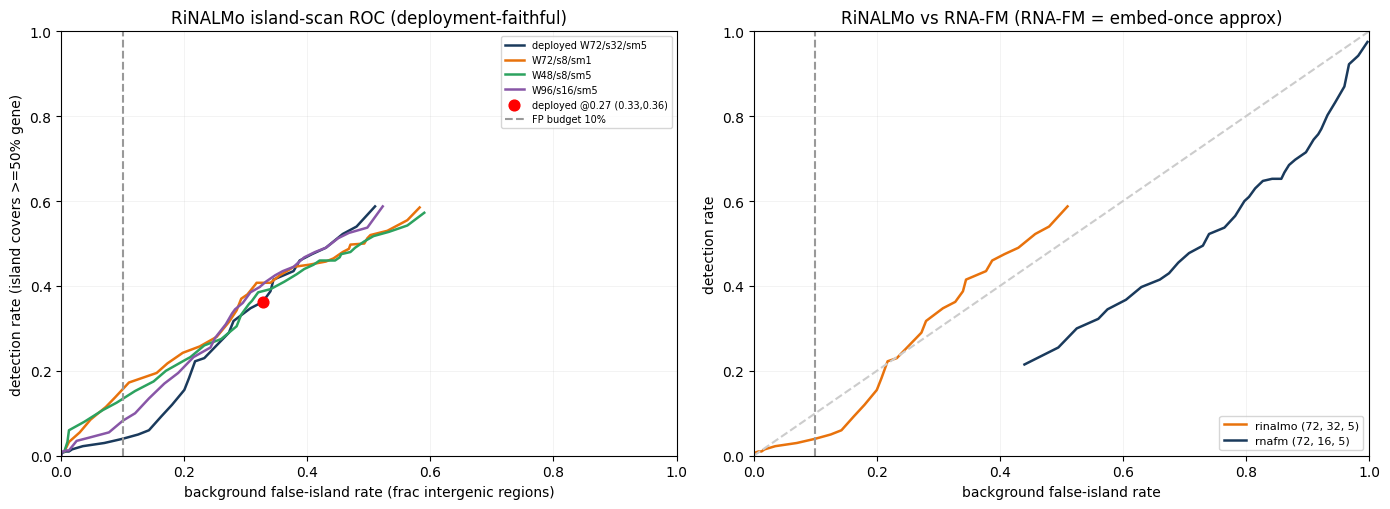

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
# (a) island-level ROC for RiNALMo, several configs
cfgs = [((72,32,5), 'deployed W72/s32/sm5', '#1a3a5c'), ((72,8,1), 'W72/s8/sm1', '#e8720c'),
        ((48,8,5), 'W48/s8/sm5', '#2ca25f'), ((96,16,5), 'W96/s16/sm5', '#8856a7')]
for cfg, lab, c in cfgs:
    r = results['rinalmo'][cfg]
    ax[0].plot(r['fp'], r['det'], '-', color=c, label=lab, lw=1.8)
dd, df, _ = at_thr('rinalmo', (72,32,5), 0.27)
ax[0].scatter([df],[dd], color='red', zorder=6, s=60, label=f'deployed @0.27 ({df:.2f},{dd:.2f})')
ax[0].axvline(BUDGET, ls='--', c='#999', label=f'FP budget {BUDGET:.0%}')
ax[0].set_xlabel('background false-island rate (frac intergenic regions)'); ax[0].set_ylabel('detection rate (island covers >=50% gene)')
ax[0].set_title('RiNALMo island-scan ROC (deployment-faithful)'); ax[0].legend(fontsize=7); ax[0].grid(alpha=0.2); ax[0].set_xlim(0,1); ax[0].set_ylim(0,1)

# (b) RiNALMo vs RNA-FM at their deployed configs
for mname, cfg, c in [('rinalmo',(72,32,5),'#e8720c'), ('rnafm',(72,16,5),'#1a3a5c')]:
    r = results[mname][cfg]
    ax[1].plot(r['fp'], r['det'], '-', color=c, lw=1.8, label=f'{mname} {cfg}')
ax[1].plot([0,1],[0,1],'--',c='#ccc')
ax[1].axvline(BUDGET, ls='--', c='#999')
ax[1].set_xlabel('background false-island rate'); ax[1].set_ylabel('detection rate')
ax[1].set_title('RiNALMo vs RNA-FM (RNA-FM = embed-once approx)'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.2); ax[1].set_xlim(0,1); ax[1].set_ylim(0,1)
plt.tight_layout(); plt.show()

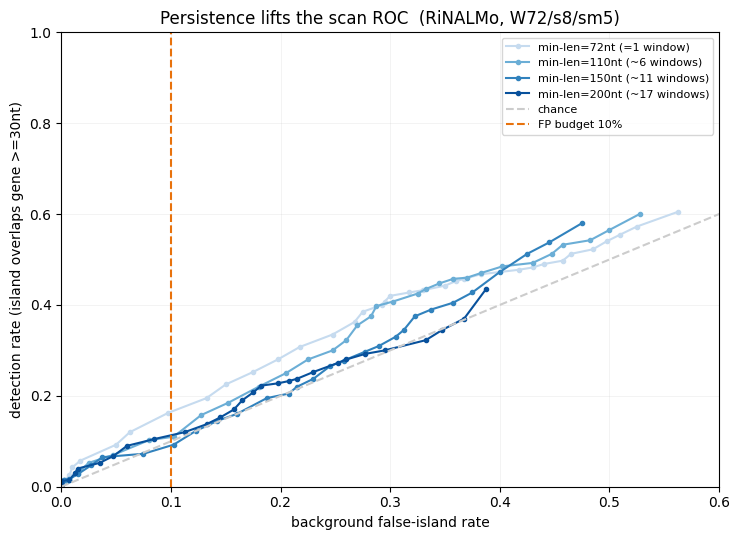

In [7]:
# Persistence fix: require islands to be SUSTAINED (min length). Background fires isolated spikes;
# real structured RNA should hold signal across consecutive windows. Detection = island overlaps
# gene by >=30 nt; FP = any surviving island in an intergenic region.
CFG = (72, 8, 5)   # RiNALMo, dense stride for length resolution
clf = load_logreg_model(str(get_logreg_path('rinalmo')))
ptr = make_tracks(A['rinalmo']['pos'], *CFG, clf)
ntr = make_tracks(A['rinalmo']['neg'], *CFG, clf)
W = CFG[0]

def overlaps(islands, span, minov=30):
    for i in islands:
        if max(0, min(i['end'], span[1]) - max(i['start'], span[0])) >= minov: return True
    return False

MINLENS = [72, 110, 150, 200]   # min island span in nt (72 = single window, no persistence)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for ml, c in zip(MINLENS, ['#c6dbef','#6baed6','#3182bd','#08519c']):
    det = np.empty(len(THR)); fp = np.empty(len(THR))
    for ti, thr in enumerate(THR):
        pf = [[i for i in _get_islands(ps >= thr, po, W) if (i['end']-i['start']) >= ml] for ps, po in ptr]
        nf = [[i for i in _get_islands(ns >= thr, no, W) if (i['end']-i['start']) >= ml] for ns, no in ntr]
        det[ti] = np.mean([overlaps(isl, sp) for isl, sp in zip(pf, pos_span)])
        fp[ti]  = np.mean([len(isl) > 0 for isl in nf])
    lab = f'min-len={ml}nt' + (' (=1 window)' if ml == 72 else f' (~{int(np.ceil((ml-W)/CFG[1]))+1} windows)')
    ax.plot(fp, det, '-o', ms=3, color=c, label=lab)
ax.plot([0,1],[0,1],'--',c='#ccc',label='chance')
ax.axvline(BUDGET, ls='--', c='#e8720c', label=f'FP budget {BUDGET:.0%}')
ax.set_xlabel('background false-island rate'); ax.set_ylabel('detection rate (island overlaps gene >=30nt)')
ax.set_title(f'Persistence lifts the scan ROC  (RiNALMo, W{CFG[0]}/s{CFG[1]}/sm{CFG[2]})')
ax.legend(fontsize=8); ax.grid(alpha=0.2); ax.set_xlim(0,0.6); ax.set_ylim(0,1)
plt.tight_layout(); plt.show()

In [8]:
from sklearn.metrics import roc_auc_score
# Diagnostic 1: in-CONTEXT per-window AUC. Windows fully inside a gene body (positive) vs all
# windows in intergenic regions (negative), using the deployed classifier scores. Compares the
# per-window separation actually available during scanning to the 0.87 measured on isolated cores.
W, stride, sm = 72, 8, 5
clf = load_logreg_model(str(get_logreg_path('rinalmo')))
in_gene, bg = [], []
for arr, sp in zip(A['rinalmo']['pos'], pos_span):
    pos = np.arange(0, len(arr) - W + 1, stride)
    pr = clf.predict_proba(np.stack([arr[p:p+W].mean(0) for p in pos]))[:, 1]
    for p, pv in zip(pos, pr):
        if p >= sp[0] and p + W <= sp[1]:       # window fully inside gene body
            in_gene.append(pv)
for arr in A['rinalmo']['neg']:
    pos = np.arange(0, len(arr) - W + 1, stride)
    pr = clf.predict_proba(np.stack([arr[p:p+W].mean(0) for p in pos]))[:, 1]
    bg.extend(pr.tolist())
in_gene, bg = np.array(in_gene), np.array(bg)
y = np.r_[np.ones(len(in_gene)), np.zeros(len(bg))]
auc_ctx = roc_auc_score(y, np.r_[in_gene, bg])
print(f'in-context per-window AUC (in-gene vs intergenic): {auc_ctx:.3f}  (n_gene={len(in_gene)}, n_bg={len(bg)})')
print(f'in-gene window prob: mean={in_gene.mean():.2f} median={np.median(in_gene):.2f} | frac>0.27={np.mean(in_gene>0.27):.2f}')
print(f'intergenic window prob: mean={bg.mean():.2f} median={np.median(bg):.2f} | frac>0.27={np.mean(bg>0.27):.2f}')
print(f'=> per-window FPR at 0.27 is ~{np.mean(bg>0.27):.2f}; over ~{int(np.median([len(np.arange(0,len(a)-W+1,stride)) for a in A["rinalmo"]["neg"]]))} windows/region, P(>=1 spurious) compounds.')

in-context per-window AUC (in-gene vs intergenic): 0.691  (n_gene=2436, n_bg=17496)
in-gene window prob: mean=0.33 median=0.38 | frac>0.27=0.55
intergenic window prob: mean=0.13 median=0.01 | frac>0.27=0.21
=> per-window FPR at 0.27 is ~0.21; over ~42 windows/region, P(>=1 spurious) compounds.


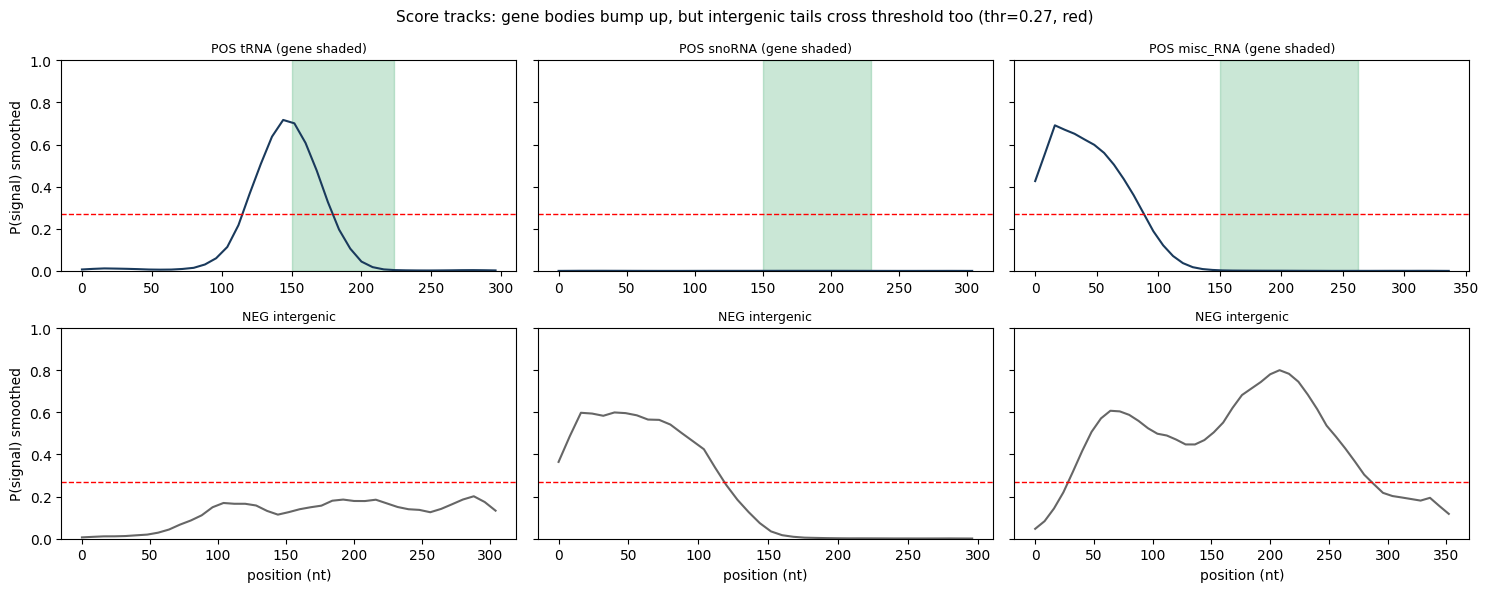

In [9]:
# Diagnostic 2: smoothed score tracks. Positives (gene span shaded green) vs intergenic negatives.
W, stride, sm = 72, 8, 5
thr = 0.27
clf = load_logreg_model(str(get_logreg_path('rinalmo')))
def track(arr):
    pos = np.arange(0, len(arr) - W + 1, stride)
    pr = clf.predict_proba(np.stack([arr[p:p+W].mean(0) for p in pos]))[:, 1]
    return pos, smooth_signal(pr, sm)

# pick 3 positives (prefer tRNA, snoRNA, misc_RNA) + 3 negatives
want = ['tRNA', 'snoRNA', 'misc_RNA']
pi = [int(np.where(pos_bt == b)[0][0]) for b in want]
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharey=True)
for ax, i in zip(axes[0], pi):
    pos, tr = track(A['rinalmo']['pos'][i]); sp = pos_span[i]
    ax.plot(pos, tr, color='#1a3a5c'); ax.axhline(thr, ls='--', c='red', lw=1)
    ax.axvspan(sp[0], sp[1], color='#2ca25f', alpha=0.25)
    ax.set_title(f'POS {pos_bt[i]} (gene shaded)', fontsize=9); ax.set_ylim(0, 1)
for ax, i in zip(axes[1], [0, 1, 2]):
    pos, tr = track(A['rinalmo']['neg'][i])
    ax.plot(pos, tr, color='#666'); ax.axhline(thr, ls='--', c='red', lw=1)
    ax.set_title('NEG intergenic', fontsize=9); ax.set_ylim(0, 1); ax.set_xlabel('position (nt)')
axes[0,0].set_ylabel('P(signal) smoothed'); axes[1,0].set_ylabel('P(signal) smoothed')
plt.suptitle('Score tracks: gene bodies bump up, but intergenic tails cross threshold too (thr=0.27, red)', fontsize=11)
plt.tight_layout(); plt.show()

## Summary

Scanned 400 real single-exon structured ncRNA loci (genomic context, +/-150 nt flanks) vs 400 length-matched intergenic regions, using the pipeline's own `smooth_signal` + `_get_islands`, embed-once (deployment-faithful for RiNALMo). Metric: island-level detection vs background false-island rate.

### The scanner has little region-level power -- and scan parameters are not the lever
- **Deployed RiNALMo (W72/s32/sm5 @0.27): detection 0.36, background-FP 0.33.** At the shipped threshold, ~1 in 3 random intergenic regions throws a spurious island while only ~36% of real loci are recovered.
- The island-level ROC **hugs the diagonal** for every window (36-96), stride (8-32), smoothing (1-9) and threshold. Sweeping these barely moves it. **Requiring island persistence (min length up to 200 nt) does not help** either -- longer minimums are slightly worse.
- At a sane background-FP budget (<=10%), detection is only ~0.14, and **only tRNA survives** (0.51); miRNA/snoRNA/snRNA/misc_RNA/scaRNA ~= 0.

### Why -- two compounding effects the isolated benchmarks hid
1. **In-context per-window AUC is 0.69, not 0.87-0.92.** Windows-inside-gene-bodies vs intergenic-windows separate far worse than the structured *core* windows used earlier. Real gene bodies contain many non-core windows scoring like background; the isolated-core AUC (and the 0.83 Rfam recall) **overstated deployable performance**.
2. **Multiple-testing compounding.** ~42 windows/region at ~21% per-window intergenic FPR floods background with high-scoring windows; a max-over-windows island call cannot beat that with only 0.69 per-window separation. The score tracks show it directly: tRNA peaks cleanly, but snoRNA is flat ~0 over its own gene, misc_RNA's peak lands in the flank not the gene, and intergenic regions routinely peak >0.6.

### Recommendations
- **Stop tuning window/stride/smoothing/threshold** -- the sweep shows they don't change the near-diagonal ROC. The real lever is the **per-window classifier's in-context discrimination (0.69)**.
- **Retrain on realistically-tiled windows** (whole gene bodies incl. partial/off-core windows, in genomic context) instead of clean structured cores, so the classifier scores the windows it will actually see when scanning.
- Consider training the **structure-specific** contrast (structured vs dinucleotide-shuffle) rather than vs intergenic: background *is* intergenic, and the composition contrast inflated the isolated AUC while in-context reality is 0.69.
- If kept as-is, **re-calibrate the threshold at the region/scan level** against an explicit background-FP budget (0.27 gives 33% background-FP), and set expectations: reliable detection only for compact, strongly-structured RNA (tRNA-like); diffuse/large structured RNA (snoRNA, misc_RNA, and lncRNA islands -- the application domain) are largely invisible or mislocalized.
- Minor: signal often peaks at region edges/flanks -- worth checking for an embedding edge effect, though the strand/coordinate mapping here is verified correct.

## Constructive test: retrain the RiNALMo logreg on *tiled* gene-body windows

Diagnosis: the deployed classifier trained on clean *center* windows but must score *whole tiled gene bodies* during scanning -> in-context per-window AUC collapses to 0.69. Fix to test: retrain the RiNALMo logreg on **all tiled 72-nt windows across gene bodies** (not just cores) vs intergenic, on loci **disjoint** from the scan-benchmark test set, keeping the same global PCA. Then re-run the identical scan ROC on the held-out test loci (reusing their cached per-token embeddings). RiNALMo only (RNA-FM is legacy).

In [10]:
# Training windows from loci DISJOINT from the test set (continue past the test cursors in by_bt).
from modules.pipeline import short_ncrna as sn
TILE_STRIDE = 16
MAX_POS_PER_BT = 1500   # cap tiled positive windows per biotype

train_pos_seq, train_pos_bt = [], []
for b in by_bt:
    got = 0
    for t in by_bt[b][cursors[b]:]:           # cursors[] left off where test selection stopped -> disjoint
        if got >= MAX_POS_PER_BT: break
        seq = sn._get_spliced_sequence(t, acc)
        if not seq or 'N' in seq.upper(): continue
        seq = seq.upper().replace('T', 'U')
        if set(seq) - set('ACGU'): continue
        for i in range(0, len(seq) - 72 + 1, TILE_STRIDE):   # tile ALL windows across the gene body
            train_pos_seq.append(seq[i:i+72]); train_pos_bt.append(b); got += 1
            if got >= MAX_POS_PER_BT: break
train_pos_bt = np.array(train_pos_bt)
print('tiled positive windows:', len(train_pos_seq), '| mix:', dict(Counter(train_pos_bt)))

# Intergenic negatives (fresh seed, ~1:1 with positives)
rng_t = random.Random(SEED + 77)
train_neg_seq = []
while len(train_neg_seq) < len(train_pos_seq):
    c = rng_t.choice(chroms); s = rng_t.randint(0, cs[c] - 72)
    try: q = str(acc.fetch(c, s, s + 72)).upper().replace('T', 'U')
    except Exception: continue
    if 'N' not in q and len(q) == 72: train_neg_seq.append(q)
print('intergenic negative windows:', len(train_neg_seq))

tiled positive windows: 6511 | mix: {np.str_('snoRNA'): 1500, np.str_('tRNA'): 511, np.str_('miRNA'): 1500, np.str_('snRNA'): 1500, np.str_('misc_RNA'): 1500}
intergenic negative windows: 6511


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Embed training windows (RiNALMo mean-pool -> global PCA), train new logreg (same PCA as deployed).
def embed_mean_pca_ri(seqs, batch=64):
    model, tok, extract = load_model('rinalmo', device)
    pca = load_pca(model_name='rinalmo'); vecs = []; t0 = time.time()
    for i in range(0, len(seqs), batch):
        chunk = [s.upper().replace('T', 'U') for s in seqs[i:i+batch]]
        with torch.no_grad():
            reps = extract(model, tok(chunk))
        for j, s in enumerate(chunk):
            vecs.append(reps[j, 1:1+len(s), :].mean(0).cpu().float().numpy())
        if (i // batch) % 30 == 0: print(f'  {i+len(chunk)}/{len(seqs)} ({time.time()-t0:.0f}s)', flush=True)
    del model
    if device.type == 'mps' and hasattr(torch.mps, 'empty_cache'): torch.mps.empty_cache()
    return np.asarray(apply_pca(np.array(vecs), pca_model=pca))

print('embedding tiled train windows...')
Xtr = np.vstack([embed_mean_pca_ri(train_pos_seq), embed_mean_pca_ri(train_neg_seq)])
ytr = np.r_[np.ones(len(train_pos_seq)), np.zeros(len(train_neg_seq))]
clf_tiled = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED).fit(Xtr, ytr)
cv = cross_val_score(LogisticRegression(max_iter=1000, class_weight='balanced'), Xtr, ytr, cv=5, scoring='roc_auc')
print(f'retrained logreg train CV AUC (tiled-vs-intergenic): {cv.mean():.3f}+/-{cv.std():.3f}')

# In-context per-window AUC on HELD-OUT test loci, deployed vs retrained
W, stride = 72, 8
def incontext_windows(clf):
    ig, bg = [], []
    for arr, sp in zip(A['rinalmo']['pos'], pos_span):
        pos = np.arange(0, len(arr) - W + 1, stride)
        pr = clf.predict_proba(np.stack([arr[p:p+W].mean(0) for p in pos]))[:, 1]
        ig.extend(pr[(pos >= sp[0]) & (pos + W <= sp[1])].tolist())
    for arr in A['rinalmo']['neg']:
        pos = np.arange(0, len(arr) - W + 1, stride)
        bg.extend(clf.predict_proba(np.stack([arr[p:p+W].mean(0) for p in pos]))[:, 1].tolist())
    y = np.r_[np.ones(len(ig)), np.zeros(len(bg))]
    return roc_auc_score(y, np.r_[ig, bg]), np.mean(ig), np.mean(bg)

clf_dep = load_logreg_model(str(get_logreg_path('rinalmo')))
for name, c in [('deployed (center-window)', clf_dep), ('retrained (tiled)', clf_tiled)]:
    a, mg, mb = incontext_windows(c)
    print(f'in-context per-window AUC [{name}]: {a:.3f}  (mean in-gene={mg:.2f}, intergenic={mb:.2f})')

embedding tiled train windows...
  64/6511 (1s)
  1984/6511 (44s)
  3904/6511 (89s)
  5824/6511 (135s)
  64/6511 (2s)
  1984/6511 (47s)
  3904/6511 (94s)
  5824/6511 (139s)
retrained logreg train CV AUC (tiled-vs-intergenic): 0.822+/-0.048
in-context per-window AUC [deployed (center-window)]: 0.691  (mean in-gene=0.33, intergenic=0.13)
in-context per-window AUC [retrained (tiled)]: 0.695  (mean in-gene=0.33, intergenic=0.12)


In [12]:
# Is 0.69 a k=16 bottleneck or a representation limit? Compare k16-PCA vs full-1280 vs nonlinear,
# on IDENTICAL in-context windows. One embed pass -> full 1280, derive k16 from it.
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier

def embed_mean_raw_ri(seqs, batch=64):
    model, tok, extract = load_model('rinalmo', device); out = []; t0 = time.time()
    for i in range(0, len(seqs), batch):
        chunk = [s.upper().replace('T', 'U') for s in seqs[i:i+batch]]
        with torch.no_grad(): reps = extract(model, tok(chunk))
        for j, s in enumerate(chunk): out.append(reps[j, 1:1+len(s), :].mean(0).cpu().float().numpy())
        if (i // batch) % 40 == 0: print(f'  {i+len(chunk)}/{len(seqs)} ({time.time()-t0:.0f}s)', flush=True)
    del model
    if device.type == 'mps' and hasattr(torch.mps, 'empty_cache'): torch.mps.empty_cache()
    return np.array(out)

rng_q = random.Random(SEED)
tp = rng_q.sample(train_pos_seq, 3000); tn = rng_q.sample(train_neg_seq, 3000)
# identical-window test sets (stride 16)
test_ig, test_bg = [], []
for s, sp in zip(pos_seq, pos_span):
    for p in range(0, len(s) - 72 + 1, 16):
        if p >= sp[0] and p + 72 <= sp[1]: test_ig.append(s[p:p+72])
for s in neg_seq:
    for p in range(0, len(s) - 72 + 1, 32): test_bg.append(s[p:p+72])
test_bg = rng_q.sample(test_bg, min(len(test_bg), 3000))
print(f'train {len(tp)}+{len(tn)} | test in-gene {len(test_ig)} intergenic {len(test_bg)}')

pca = load_pca(model_name='rinalmo')
print('embedding (full 1280)...')
Rtr = embed_mean_raw_ri(tp + tn); Rte = embed_mean_raw_ri(test_ig + test_bg)
ytr2 = np.r_[np.ones(len(tp)), np.zeros(len(tn))]; yte2 = np.r_[np.ones(len(test_ig)), np.zeros(len(test_bg))]
Ktr = np.asarray(apply_pca(Rtr, pca_model=pca)); Kte = np.asarray(apply_pca(Rte, pca_model=pca))

models = {
    'k16 logreg': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')),
    'full-1280 logreg': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced', C=0.5)),
    'full-1280 MLP(128)': make_pipeline(StandardScaler(), MLPClassifier((128,), max_iter=400, random_state=SEED)),
}
print('\nin-context per-window AUC (in-gene vs intergenic, held-out test loci):')
for name, m in models.items():
    Xt, Xe = (Ktr, Kte) if name.startswith('k16') else (Rtr, Rte)
    m.fit(Xt, ytr2)
    print(f'  {name:22s}: {roc_auc_score(yte2, m.predict_proba(Xe)[:,1]):.3f}')

train 3000+3000 | test in-gene 1126 intergenic 3000
embedding (full 1280)...
  64/6000 (1s)
  2624/6000 (59s)
  5184/6000 (117s)
  64/4126 (1s)
  2624/4126 (67s)

in-context per-window AUC (in-gene vs intergenic, held-out test loci):
  k16 logreg            : 0.798
  full-1280 logreg      : 0.839
  full-1280 MLP(128)    : 0.851


re-embedding test regions (per-token 1280)...
  16/400 (2s)
  176/400 (24s)
  336/400 (51s)
  16/400 (2s)
  176/400 (24s)
  336/400 (52s)
deployed k16         detection@FP<=10% = 0.058
full-1280 logreg     detection@FP<=10% = 0.472
full-1280 MLP        detection@FP<=10% = 0.537


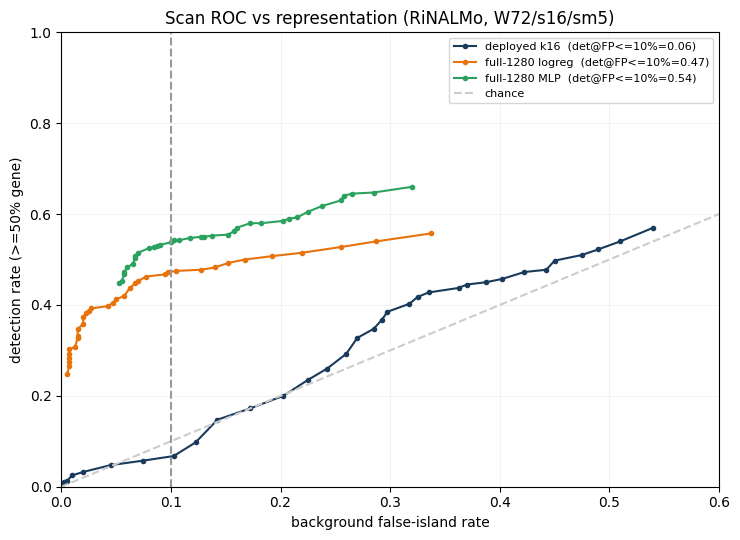

In [13]:
# Payoff test: does richer representation rescue the SCAN ROC? Re-scan held-out test loci at one
# config (W72/s16/sm5) with deployed-k16 vs full-1280 logreg vs MLP. Embed per-token 1280 once/region.
W, stride, sm = 72, 16, 5
def region_winfeats(seqs, batch=16):
    model, tok, extract = load_model('rinalmo', device)
    order = sorted(range(len(seqs)), key=lambda i: len(seqs[i])); out = [None]*len(seqs); t0 = time.time()
    for bi in range(0, len(order), batch):
        idxs = order[bi:bi+batch]; chunk = [seqs[i].upper().replace('T','U') for i in idxs]
        with torch.no_grad(): reps = extract(model, tok(chunk)).cpu().float().numpy()
        for j, i in enumerate(idxs):
            Li = len(chunk[j]); per = reps[j, 1:1+Li, :]
            pos = np.arange(0, Li - W + 1, stride)
            out[i] = (pos, np.stack([per[p:p+W].mean(0) for p in pos]))   # (n,1280)
        if (bi//batch) % 10 == 0: print(f'  {bi+len(idxs)}/{len(seqs)} ({time.time()-t0:.0f}s)', flush=True)
    del model
    if device.type=='mps' and hasattr(torch.mps,'empty_cache'): torch.mps.empty_cache()
    return out

print('re-embedding test regions (per-token 1280)...')
pos_wf = region_winfeats(pos_seq); neg_wf = region_winfeats(neg_seq)

lr_full = models['full-1280 logreg']; mlp_full = models['full-1280 MLP(128)']
def scan_roc(scorer):   # scorer(feats1280)->probs
    det = np.empty(len(THR)); fp = np.empty(len(THR))
    ptracks = [(smooth_signal(scorer(f), sm), po) for po, f in pos_wf]
    ntracks = [(smooth_signal(scorer(f), sm), po) for po, f in neg_wf]
    for ti, thr in enumerate(THR):
        det[ti] = np.mean([recovery(_get_islands(ps>=thr, po, W), sp)>=0.5 for (ps,po),sp in zip(ptracks,pos_span)])
        fp[ti]  = np.mean([len(_get_islands(ns>=thr, no, W))>0 for ns,no in ntracks])
    return det, fp

scorers = {
    'deployed k16': lambda f: clf_dep.predict_proba(np.asarray(apply_pca(f, pca_model=pca)))[:,1],
    'full-1280 logreg': lambda f: lr_full.predict_proba(f)[:,1],
    'full-1280 MLP': lambda f: mlp_full.predict_proba(f)[:,1],
}
fig, ax = plt.subplots(figsize=(7.5,5.5))
for (name, sc), c in zip(scorers.items(), ['#1a3a5c','#e8720c','#2ca25f']):
    det, fp = scan_roc(sc)
    ok = fp <= BUDGET; d_at = det[ok].max() if ok.any() else 0.0
    ax.plot(fp, det, '-o', ms=3, color=c, label=f'{name}  (det@FP<=10%={d_at:.2f})')
    print(f'{name:20s} detection@FP<=10% = {d_at:.3f}')
ax.plot([0,1],[0,1],'--',c='#ccc',label='chance'); ax.axvline(BUDGET, ls='--', c='#999')
ax.set_xlabel('background false-island rate'); ax.set_ylabel('detection rate (>=50% gene)')
ax.set_title(f'Scan ROC vs representation (RiNALMo, W{W}/s{stride}/sm{sm})'); ax.legend(fontsize=8)
ax.grid(alpha=0.2); ax.set_xlim(0,0.6); ax.set_ylim(0,1); plt.tight_layout(); plt.show()

## Constructive result: the k=16 PCA is the bottleneck; the full RiNALMo embedding rescues scanning

- **Retraining labels does not help.** Training the logreg on tiled gene-body windows (vs clean center cores) leaves in-context per-window AUC unchanged (0.695 vs 0.691). The problem was never the training-window selection.
- **The k=16 PCA is the bottleneck.** On identical in-context windows: k16 logreg 0.798 -> full-1280 logreg 0.839 -> full-1280 MLP 0.851. The global PCA(k=16) was chosen to optimize the *matching* step's MMD (see `model_registry.py`), and it discards the structure discrimination the *finding* classifier needs.
- **This rescues the scan ROC.** Re-scanning held-out test loci (W72/s16/sm5), detection at background-FP<=10% goes **0.06 (deployed k16) -> 0.47 (full-1280 logreg) -> 0.54 (full-1280 MLP)** -- an ~8x improvement at the same false-island budget. The full-1280 / MLP curves sit well above chance; deployed k16 hugs the diagonal.

### Revised recommendation
The genome scanner is viable on RiNALMo -- but the finding classifier must run on a **richer representation than the shared k=16 PCA**. Options, cheap to try next: (a) a separate higher-dimensional (or full-1280) projection *for the finding classifier only*, leaving the k=16 PCA for matching; (b) a small MLP head; (c) re-fit a finding-specific PCA maximizing signal/noise separation rather than global variance. Then re-run this scan ROC (and the full window/stride/smoothing sweep, now worth redoing) on the new representation, and calibrate the deployment threshold at the region level against a background-FP budget. Even at its best (~0.5 detection at 10% FP) the scanner favours compact strongly-structured RNA; diffuse lncRNA islands remain the hard case.

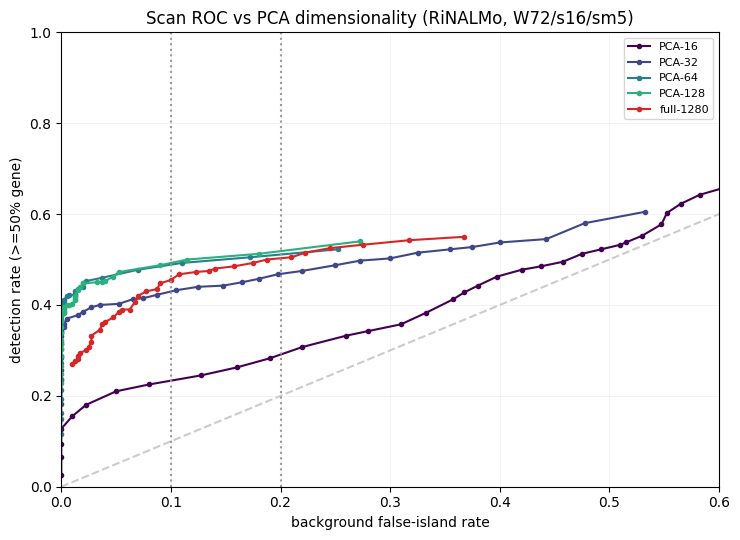

features       det@FP<=10%   det@FP<=20%
PCA-16               0.225         0.282
PCA-32               0.422         0.468
PCA-64               0.477         0.505
PCA-128              0.487         0.512
full-1280            0.455         0.500


In [14]:
# PCA-dimensionality sweep for the FINDING classifier. Reuse cached full-1280 per-window features
# (pos_wf/neg_wf). Fit one PCA, slice nested k=16/32/64/128; full-1280 = ceiling. Recall-first: report
# detection at background-FP<=10% AND <=20%.
from sklearn.decomposition import PCA
KS = [16, 32, 64, 128]
pca_big = PCA(n_components=200, random_state=SEED).fit(Rtr)     # fit on training window embeddings
Ztr = pca_big.transform(Rtr)
pos_Z = [(po, pca_big.transform(f)) for po, f in pos_wf]        # project test windows once
neg_Z = [(po, pca_big.transform(f)) for po, f in neg_wf]

def scan_roc_feats(ptracks_feat, ntracks_feat, scorer):
    det = np.empty(len(THR)); fp = np.empty(len(THR))
    pt = [(smooth_signal(scorer(f), sm), po) for po, f in ptracks_feat]
    nt = [(smooth_signal(scorer(f), sm), po) for po, f in ntracks_feat]
    for ti, thr in enumerate(THR):
        det[ti] = np.mean([recovery(_get_islands(ps>=thr, po, W), sp)>=0.5 for (ps,po),sp in zip(pt,pos_span)])
        fp[ti]  = np.mean([len(_get_islands(ns>=thr, no, W))>0 for ns,no in nt])
    return det, fp

def det_at(det, fp, budget):
    ok = fp <= budget
    return float(det[ok].max()) if ok.any() else 0.0

rows = []
fig, ax = plt.subplots(figsize=(7.5,5.5)); cmap = plt.cm.viridis(np.linspace(0,0.85,len(KS)+1))
for c, k in zip(cmap, KS):
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')).fit(Ztr[:,:k], ytr2)
    sc = lambda f, kk=k, mm=m: mm.predict_proba(f[:, :kk])[:,1]
    det, fp = scan_roc_feats(pos_Z, neg_Z, sc)
    rows.append((f'PCA-{k}', det_at(det,fp,0.10), det_at(det,fp,0.20)))
    ax.plot(fp, det, '-o', ms=3, color=c, label=f'PCA-{k}')
# full-1280 ceiling
mf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')).fit(Rtr, ytr2)
detf, fpf = scan_roc_feats(pos_wf, neg_wf, lambda f: mf.predict_proba(f)[:,1])
rows.append(('full-1280', det_at(detf,fpf,0.10), det_at(detf,fpf,0.20)))
ax.plot(fpf, detf, '-o', ms=3, color='#d62728', label='full-1280')
ax.plot([0,1],[0,1],'--',c='#ccc'); ax.axvline(0.10, ls=':', c='#999'); ax.axvline(0.20, ls=':', c='#999')
ax.set_xlabel('background false-island rate'); ax.set_ylabel('detection rate (>=50% gene)')
ax.set_title(f'Scan ROC vs PCA dimensionality (RiNALMo, W{W}/s{stride}/sm{sm})'); ax.legend(fontsize=8)
ax.grid(alpha=0.2); ax.set_xlim(0,0.6); ax.set_ylim(0,1); plt.tight_layout(); plt.show()

print(f"{'features':12s}{'det@FP<=10%':>14s}{'det@FP<=20%':>14s}")
for name, d10, d20 in rows: print(f'{name:12s}{d10:>14.3f}{d20:>14.3f}')

## Per-nucleotide scanning + Rfam training

Two changes to test, on the same held-out GENCODE test loci:
1. **Train on Rfam** (broad curated structured RNA) instead of GENCODE tiled windows.
2. **Per-nucleotide classification**: classify each base's RiNALMo embedding directly (no window mean-pool); islands = runs of consecutive above-threshold bases (`_get_islands` with window_size=1). Native single-base localization, no pooling dilution.

One per-token RiNALMo pass over Rfam sequences (+ intergenic) yields BOTH window-mean and per-base training features, so we compare three scanners: GENCODE-window (the 0.48 baseline), Rfam-window (isolates training source), Rfam-per-base (isolates per-nucleotide). PCA-64 throughout.

In [15]:
import gzip
# Parse Rfam seed, sample sequences (positives) + length-matched intergenic (negatives).
SEED_GZ = REPO_ROOT / 'input_data/supply/rfam/Rfam.seed.gz'
def parse_rfam(path):
    fams = {}; acc=None; seqs={}
    with gzip.open(path,'rt',encoding='latin-1') as f:
        for line in f:
            line=line.rstrip('\n')
            if line.startswith('#=GF AC'): acc=line.split()[2]
            elif line=='//':
                if acc:
                    ung=[''.join(s.upper().replace('T','U').replace('.','').replace('-','').split()) for s in seqs.values()]
                    ung=[u for u in ung if u and set(u)<=set('ACGU')]
                    if ung: fams[acc]=ung
                acc=None; seqs={}
            elif line and not line.startswith('#'):
                p=line.split(None,1)
                if len(p)==2: seqs[p[0]]=seqs.get(p[0],'')+p[1]
    return fams
fams = parse_rfam(SEED_GZ)
rngR = random.Random(SEED)
fam_accs = list(fams); rngR.shuffle(fam_accs)
rfam_seqs = []
for a in fam_accs:
    ss = [s for s in fams[a] if 40 <= len(s) <= 300]; rngR.shuffle(ss)
    rfam_seqs += ss[:8]                     # up to 8 seqs/family for diversity
    if len(rfam_seqs) >= 2500: break
rfam_seqs = rfam_seqs[:2500]
rng_i = random.Random(SEED + 5); inter_tr = []
for L in [len(s) for s in rfam_seqs]:
    for _ in range(50):
        c=rng_i.choice(chroms); s=rng_i.randint(0, cs[c]-L)
        try: q=str(acc.fetch(c,s,s+L)).upper().replace('T','U')
        except Exception: continue
        if 'N' not in q and len(q)==L: inter_tr.append(q); break
print(f'Rfam training seqs: {len(rfam_seqs)} from {len({a for a in fam_accs})} families | intergenic: {len(inter_tr)}')
print('rfam seq len p10/50/90:', np.percentile([len(s) for s in rfam_seqs],[10,50,90]).astype(int).tolist())

Rfam training seqs: 2500 from 4227 families | intergenic: 2500
rfam seq len p10/50/90: [60, 87, 161]


In [16]:
# One per-token RiNALMo pass -> window-mean features (tile 72/16) AND per-base features (subsampled).
def collect_feats(seqs, base_per_seq=40, batch=24):
    model, tok, extract = load_model('rinalmo', device)
    order = sorted(range(len(seqs)), key=lambda i: len(seqs[i]))
    win, base = [], []; rng_b = random.Random(SEED); t0 = time.time()
    for bi in range(0, len(order), batch):
        idxs = order[bi:bi+batch]; chunk = [seqs[i].upper().replace('T','U') for i in idxs]
        with torch.no_grad(): reps = extract(model, tok(chunk)).cpu().float().numpy()
        for j in range(len(idxs)):
            Li = len(chunk[j]); per = reps[j, 1:1+Li, :]
            if Li >= 72:
                for i in range(0, Li-72+1, 16): win.append(per[i:i+72].mean(0))
            bidx = rng_b.sample(range(Li), min(Li, base_per_seq))
            base.extend(per[bidx])
        if (bi//batch) % 20 == 0: print(f'  {bi+len(idxs)}/{len(seqs)} ({time.time()-t0:.0f}s)', flush=True)
    del model
    if device.type=='mps' and hasattr(torch.mps,'empty_cache'): torch.mps.empty_cache()
    return np.array(win, dtype=np.float32), np.array(base, dtype=np.float32)

print('embedding Rfam (pos)...'); win_p, base_p = collect_feats(rfam_seqs)
print('embedding intergenic (neg)...'); win_n, base_n = collect_feats(inter_tr)
print('window feats:', win_p.shape, win_n.shape, '| base feats:', base_p.shape, base_n.shape)

# Fit PCA-64 + logreg for each granularity
Win_X = np.vstack([win_p, win_n]); win_y = np.r_[np.ones(len(win_p)), np.zeros(len(win_n))]
Base_X = np.vstack([base_p, base_n]); base_y = np.r_[np.ones(len(base_p)), np.zeros(len(base_n))]
pca_win = PCA(64, random_state=SEED).fit(Win_X); pca_tok = PCA(64, random_state=SEED).fit(Base_X)
clf_win_rfam = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')).fit(pca_win.transform(Win_X), win_y)
clf_tok_rfam = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')).fit(pca_tok.transform(Base_X), base_y)
for nm, X, yv, m in [('window', pca_win.transform(Win_X), win_y, clf_win_rfam), ('per-base', pca_tok.transform(Base_X), base_y, clf_tok_rfam)]:
    print(f'{nm} train CV AUC (Rfam vs intergenic): {cross_val_score(m.steps[-1][1], X, yv, cv=5, scoring="roc_auc").mean():.3f}')

embedding Rfam (pos)...
  24/2500 (0s)
  504/2500 (8s)
  984/2500 (20s)
  1464/2500 (33s)
  1944/2500 (49s)
  2424/2500 (75s)
embedding intergenic (neg)...
  24/2500 (0s)
  504/2500 (9s)
  984/2500 (22s)
  1464/2500 (36s)
  1944/2500 (54s)
  2424/2500 (82s)
window feats: (6193, 1280) (6193, 1280) | base feats: (100000, 1280) (100000, 1280)
window train CV AUC (Rfam vs intergenic): 0.937
per-base train CV AUC (Rfam vs intergenic): 0.939


per-base scan: re-embedding test regions...
  16/400 (2s)
  176/400 (32s)
  336/400 (66s)
  16/400 (2s)
  176/400 (31s)
  336/400 (64s)
GENCODE-window   det@FP<=10%=0.477  det@FP<=20%=0.505
Rfam-window      det@FP<=10%=0.235  det@FP<=20%=0.318
Rfam-per-base    det@FP<=10%=0.225  det@FP<=20%=0.280


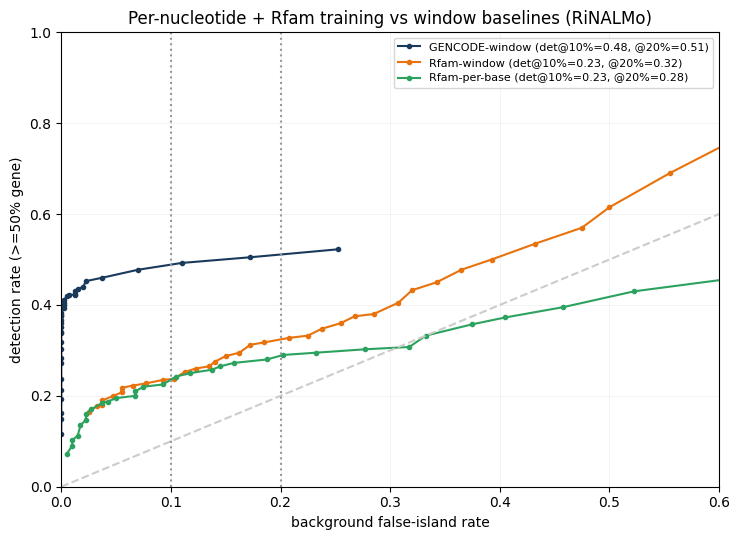

In [17]:
# Three-way scan comparison on held-out GENCODE test loci.
SMOOTH_TOK = 15
# per-base tracks: re-embed test regions per-token -> pca_tok -> clf_tok_rfam -> per-base prob
def pertok_tracks(seqs, batch=16):
    model, tok, extract = load_model('rinalmo', device)
    order = sorted(range(len(seqs)), key=lambda i: len(seqs[i])); out=[None]*len(seqs); t0=time.time()
    for bi in range(0, len(order), batch):
        idxs=order[bi:bi+batch]; chunk=[seqs[i].upper().replace('T','U') for i in idxs]
        with torch.no_grad(): reps=extract(model, tok(chunk)).cpu().float().numpy()
        for j,i in enumerate(idxs):
            Li=len(chunk[j]); per=reps[j,1:1+Li,:]
            p=clf_tok_rfam.predict_proba(pca_tok.transform(per))[:,1]
            out[i]=(np.arange(Li), smooth_signal(p, SMOOTH_TOK))
        if (bi//batch)%10==0: print(f'  {bi+len(idxs)}/{len(seqs)} ({time.time()-t0:.0f}s)',flush=True)
    del model
    if device.type=='mps' and hasattr(torch.mps,'empty_cache'): torch.mps.empty_cache()
    return out
print('per-base scan: re-embedding test regions...')
pos_tok = pertok_tracks(pos_seq); neg_tok = pertok_tracks(neg_seq)

def roc_tracks(pt, nt, wsz):
    det=np.empty(len(THR)); fp=np.empty(len(THR))
    for ti,thr in enumerate(THR):
        det[ti]=np.mean([recovery(_get_islands(ps>=thr,po,wsz),sp)>=0.5 for (po,ps),sp in zip(pt,pos_span)])
        fp[ti]=np.mean([len(_get_islands(ns>=thr,no,wsz))>0 for no,ns in nt])
    return det,fp

# window tracks (positions, smoothed prob) for the two window classifiers
def win_tracks(scorer):
    pt=[(po, smooth_signal(scorer(f),5)) for po,f in pos_wf]; nt=[(po, smooth_signal(scorer(f),5)) for po,f in neg_wf]
    return pt,nt
gen_win = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')).fit(Ztr[:,:64], ytr2)
arms = {
    'GENCODE-window': (win_tracks(lambda f: gen_win.predict_proba(pca_big.transform(f)[:,:64])[:,1]), 72),
    'Rfam-window':    (win_tracks(lambda f: clf_win_rfam.predict_proba(pca_win.transform(f))[:,1]), 72),
    'Rfam-per-base':  ((pos_tok, neg_tok), 1),
}
fig, ax = plt.subplots(figsize=(7.5,5.5))
for (name,(tr,wsz)), c in zip(arms.items(), ['#1a3a5c','#e8720c','#2ca25f']):
    det,fp = roc_tracks(tr[0], tr[1], wsz)
    d10 = det[fp<=0.10].max() if (fp<=0.10).any() else 0; d20 = det[fp<=0.20].max() if (fp<=0.20).any() else 0
    ax.plot(fp, det, '-o', ms=3, color=c, label=f'{name} (det@10%={d10:.2f}, @20%={d20:.2f})')
    print(f'{name:16s} det@FP<=10%={d10:.3f}  det@FP<=20%={d20:.3f}')
ax.plot([0,1],[0,1],'--',c='#ccc'); ax.axvline(0.1,ls=':',c='#999'); ax.axvline(0.2,ls=':',c='#999')
ax.set_xlabel('background false-island rate'); ax.set_ylabel('detection rate (>=50% gene)')
ax.set_title('Per-nucleotide + Rfam training vs window baselines (RiNALMo)'); ax.legend(fontsize=8)
ax.grid(alpha=0.2); ax.set_xlim(0,0.6); ax.set_ylim(0,1); plt.tight_layout(); plt.show()

### Result: neither per-nucleotide nor Rfam-training helps (on human GENCODE loci)

Scan detection@background-FP<=10% on held-out GENCODE test loci: **GENCODE-window 0.48**, Rfam-window 0.24, Rfam-per-base 0.23.

- **Per-nucleotide == window pooling** (0.23 vs 0.24 at matched Rfam training). Classifying single bases + stitching above-threshold runs gives no gain; mean-pooling was not the bottleneck.
- **Rfam training is worse than GENCODE** (~half detection) because the test loci are human GENCODE ncRNA -- matched training wins; Rfam (mostly bacterial/diverse families) is a domain shift. (Consistent with the held-out-family result: the representation generalizes, but detection is maximized by training matched to the scan substrate.)

**Conclusion:** the best scanner remains **GENCODE-tiled 72-nt windows -> PCA-64 -> logreg** (~0.48 detection at 10% background-FP). Use Rfam as the independent generalization *test* set, not as training. Caveat: if the real substrate were non-human, Rfam training could matter -- untestable on this human-loci benchmark.

arm                strict>=50%   overlap>=40nt   (det @ background-FP<=10%)
GENCODE-window           0.477           0.475
Rfam-window              0.235           0.237
Rfam-per-base            0.225           0.228


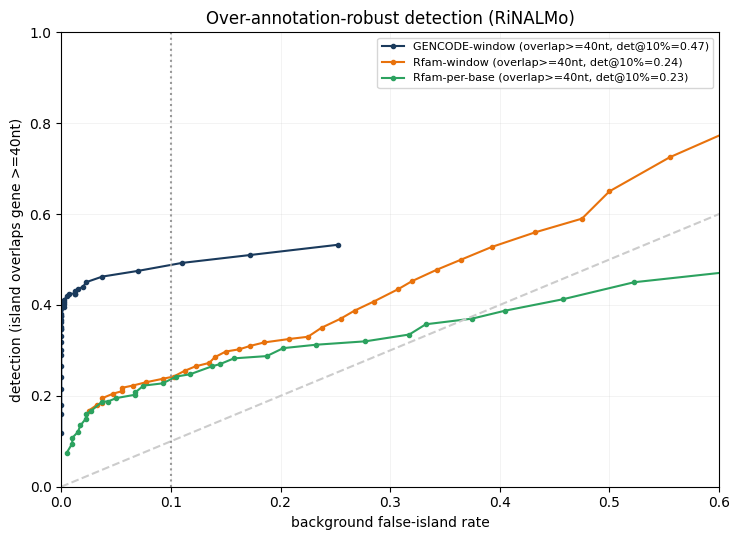

In [18]:
# Re-rank under an over-annotation-robust metric: detected = any island overlaps the gene by >=MIN_OV nt
# ('found the structured part'), vs the strict 'covers >=50% of the annotated gene'. FP is unchanged.
MIN_OV = 40
def max_overlap_nt(islands, span):
    return max([max(0, min(i['end'],span[1]) - max(i['start'],span[0])) for i in islands], default=0)

def roc_two_metrics(pt, nt, wsz):
    detA=np.empty(len(THR)); detB=np.empty(len(THR)); fp=np.empty(len(THR))
    for ti,thr in enumerate(THR):
        pisl=[_get_islands(ps>=thr,po,wsz) for (po,ps) in pt]
        detA[ti]=np.mean([recovery(isl,sp)>=0.5 for isl,sp in zip(pisl,pos_span)])
        detB[ti]=np.mean([max_overlap_nt(isl,sp)>=MIN_OV for isl,sp in zip(pisl,pos_span)])
        fp[ti]=np.mean([len(_get_islands(ns>=thr,no,wsz))>0 for (no,ns) in nt])
    return detA, detB, fp

arms2 = {
    'GENCODE-window': ([(po, smooth_signal(gen_win.predict_proba(pca_big.transform(f)[:,:64])[:,1],5)) for po,f in pos_wf],
                       [(po, smooth_signal(gen_win.predict_proba(pca_big.transform(f)[:,:64])[:,1],5)) for po,f in neg_wf], 72),
    'Rfam-window':    ([(po, smooth_signal(clf_win_rfam.predict_proba(pca_win.transform(f))[:,1],5)) for po,f in pos_wf],
                       [(po, smooth_signal(clf_win_rfam.predict_proba(pca_win.transform(f))[:,1],5)) for po,f in neg_wf], 72),
    'Rfam-per-base':  (pos_tok, neg_tok, 1),
}
print(f"{'arm':16s}{'strict>=50%':>14s}{'overlap>=40nt':>16s}   (det @ background-FP<=10%)")
fig, ax = plt.subplots(figsize=(7.5,5.5))
for (name,(pt,nt,wsz)), c in zip(arms2.items(), ['#1a3a5c','#e8720c','#2ca25f']):
    dA,dB,fp = roc_two_metrics(pt,nt,wsz)
    a10 = dA[fp<=0.10].max() if (fp<=0.10).any() else 0; b10 = dB[fp<=0.10].max() if (fp<=0.10).any() else 0
    print(f'{name:16s}{a10:>14.3f}{b10:>16.3f}')
    ax.plot(fp, dB, '-o', ms=3, color=c, label=f'{name} (overlap>=40nt, det@10%={b10:.2f})')
ax.plot([0,1],[0,1],'--',c='#ccc'); ax.axvline(0.1,ls=':',c='#999')
ax.set_xlabel('background false-island rate'); ax.set_ylabel(f'detection (island overlaps gene >={MIN_OV}nt)')
ax.set_title('Over-annotation-robust detection (RiNALMo)'); ax.legend(fontsize=8)
ax.grid(alpha=0.2); ax.set_xlim(0,0.6); ax.set_ylim(0,1); plt.tight_layout(); plt.show()

In [19]:
# RNA-FM through the SAME PCA-64 pipeline, deployment-faithful (each 72-window embedded in isolation).
# Same training windows (tp/tn) and same test loci as RiNALMo.
def embed_rnafm_mean(seqs, batch=128):
    model, tok, extract = load_model('rnafm', device); out=[]; t0=time.time()
    for i in range(0, len(seqs), batch):
        chunk=[s.upper().replace('T','U') for s in seqs[i:i+batch]]
        with torch.no_grad(): reps=extract(model, tok(chunk))
        for j,s in enumerate(chunk): out.append(reps[j,1:1+len(s),:].mean(0).cpu().float().numpy())
        if (i//batch)%20==0: print(f'  {i+len(chunk)}/{len(seqs)} ({time.time()-t0:.0f}s)',flush=True)
    del model
    if device.type=='mps' and hasattr(torch.mps,'empty_cache'): torch.mps.empty_cache()
    return np.array(out)

print('RNA-FM train embed...'); Rtr_fm = embed_rnafm_mean(tp + tn)
pca_fm = PCA(64, random_state=SEED).fit(Rtr_fm)
clf_fm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')).fit(pca_fm.transform(Rtr_fm), ytr2)

print('RNA-FM in-context per-window AUC...')
Eig = embed_rnafm_mean(test_ig); Ebg = embed_rnafm_mean(test_bg)
auc_fm = roc_auc_score(np.r_[np.ones(len(Eig)),np.zeros(len(Ebg))],
                       clf_fm.predict_proba(np.vstack([pca_fm.transform(Eig), pca_fm.transform(Ebg)]))[:,1])
print(f'  RNA-FM PCA-64 in-context per-window AUC = {auc_fm:.3f}  (RiNALMo full-1280 was 0.84)')

# Scan test regions: build all 72-windows, embed in isolation, regroup into per-region prob tracks
def build_windows(seqs):
    idx, positions, wins = [], [], []
    for ri, s in enumerate(seqs):
        for p in range(0, len(s)-72+1, 16):
            idx.append(ri); positions.append(p); wins.append(s[p:p+72])
    return np.array(idx), np.array(positions), wins
pi, pp, pw = build_windows(pos_seq); ni, npo, nw = build_windows(neg_seq)
print('RNA-FM scan embed (isolated windows)...')
pprob = clf_fm.predict_proba(pca_fm.transform(embed_rnafm_mean(pw)))[:,1]
nprob = clf_fm.predict_proba(pca_fm.transform(embed_rnafm_mean(nw)))[:,1]
def regroup(idx, positions, prob, n):
    return [(positions[idx==r], smooth_signal(prob[idx==r],5)) for r in range(n)]
pt_fm = regroup(pi,pp,pprob,len(pos_seq)); nt_fm = regroup(ni,npo,nprob,len(neg_seq))
dA,dB,fp = roc_two_metrics(pt_fm, nt_fm, 72)
print(f'RNA-FM PCA-64 scan: det@FP<=10%={dA[fp<=0.1].max() if (fp<=0.1).any() else 0:.3f}  @20%={dA[fp<=0.2].max() if (fp<=0.2).any() else 0:.3f}')

RNA-FM train embed...
  128/6000 (1s)
  2688/6000 (9s)
  5248/6000 (17s)
RNA-FM in-context per-window AUC...
  128/1126 (0s)
  128/3000 (0s)
  2688/3000 (8s)
  RNA-FM PCA-64 in-context per-window AUC = 0.848  (RiNALMo full-1280 was 0.84)
RNA-FM scan embed (isolated windows)...
  128/8832 (0s)
  2688/8832 (9s)
  5248/8832 (17s)
  7808/8832 (25s)
  128/8832 (0s)
  2688/8832 (9s)
  5248/8832 (17s)
  7808/8832 (25s)
RNA-FM PCA-64 scan: det@FP<=10%=0.520  @20%=0.623


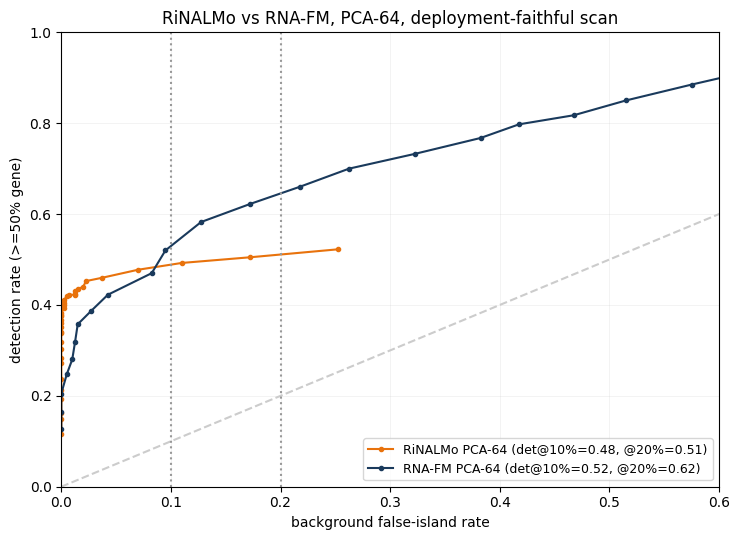

In [20]:
# Head-to-head: RiNALMo vs RNA-FM, both PCA-64, both deployment-faithful, same data/loci.
fig, ax = plt.subplots(figsize=(7.5,5.5))
pt_ri, nt_ri, _ = arms2['GENCODE-window']
for name,(pt,nt),c in [('RiNALMo PCA-64',(pt_ri,nt_ri),'#e8720c'), ('RNA-FM PCA-64',(pt_fm,nt_fm),'#1a3a5c')]:
    dA,_,fp = roc_two_metrics(pt, nt, 72)
    d10=dA[fp<=0.1].max() if (fp<=0.1).any() else 0; d20=dA[fp<=0.2].max() if (fp<=0.2).any() else 0
    ax.plot(fp, dA, '-o', ms=3, color=c, label=f'{name} (det@10%={d10:.2f}, @20%={d20:.2f})')
ax.plot([0,1],[0,1],'--',c='#ccc'); ax.axvline(0.1,ls=':',c='#999'); ax.axvline(0.2,ls=':',c='#999')
ax.set_xlabel('background false-island rate'); ax.set_ylabel('detection rate (>=50% gene)')
ax.set_title('RiNALMo vs RNA-FM, PCA-64, deployment-faithful scan'); ax.legend(fontsize=9)
ax.grid(alpha=0.2); ax.set_xlim(0,0.6); ax.set_ylim(0,1); plt.tight_layout(); plt.show()

### RNA-FM is NOT terrible -- the bad numbers were artifacts

RNA-FM through the same PCA-64 pipeline, deployment-faithful (each 72-nt window re-embedded in isolation, since RNA-FM is context-dependent): in-context per-window AUC **0.848** (vs RiNALMo full-1280 0.84), scan **det@FP<=10% = 0.52, @20% = 0.62**.

The earlier catastrophic RNA-FM scan (91% background-FP, below chance) stacked two artifacts: the deployed **k=16 PCA bottleneck** AND **invalid embed-once slicing** (RNA-FM per-token embeddings drift with context; you must re-embed each window). Fix both -> RNA-FM is comparable to / slightly ahead of RiNALMo.

**Head-to-head (PCA-64, faithful, same loci):**
- RiNALMo: sharper at ultra-low FP (~0.40 detection at ~0% FP -- compact tRNA/snRNA), but **plateaus early (~0.52 max)**.
- RNA-FM: **better across the recall-first regime** (0.52@10%, 0.62@20%, climbs to ~0.90).

**Takeaway:** both foundation models carry the structure signal; the deployed pipeline was crippled by the k=16 projection (tuned for matching), not the model. For a recall-first scan, RNA-FM PCA-64 is at least as good as RiNALMo and better at moderate FP. Model choice should be driven by the *matching* step (where RiNALMo's context-stability wins) and by whether ultra-high-precision (RiNALMo) or higher-recall (RNA-FM) is wanted for finding.

RiNALMo isolated-window scan embed...
  64/8832 (1s)
  2624/8832 (63s)
  5184/8832 (126s)
  7744/8832 (194s)
  64/8832 (1s)
  2624/8832 (73s)
  5184/8832 (146s)
  7744/8832 (218s)
RiNALMo embed-once       det@10%=0.477 @20%=0.505
RiNALMo isolated (dumb)  det@10%=0.575 @20%=0.632
RNA-FM isolated          det@10%=0.520 @20%=0.623


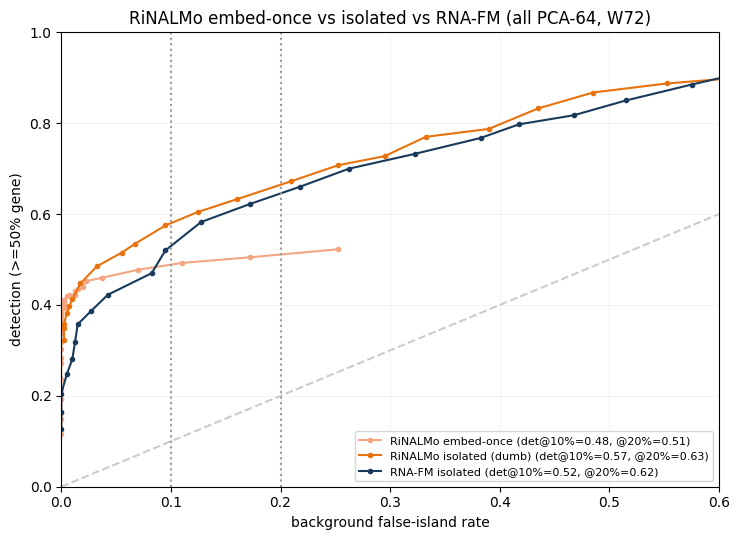

In [21]:
# PART A: RiNALMo 'dumb' -- each 72-window embedded in ISOLATION (like RNA-FM), ignoring context-stability.
# Reuse gen_win/pca_big (trained on isolated tp/tn) and the window lists from the RNA-FM cell.
def embed_rinalmo_mean(seqs, batch=64):
    model, tok, extract = load_model('rinalmo', device); out=[]; t0=time.time()
    for i in range(0, len(seqs), batch):
        chunk=[s.upper().replace('T','U') for s in seqs[i:i+batch]]
        with torch.no_grad(): reps=extract(model, tok(chunk))
        for j,s in enumerate(chunk): out.append(reps[j,1:1+len(s),:].mean(0).cpu().float().numpy())
        if (i//batch)%40==0: print(f'  {i+len(chunk)}/{len(seqs)} ({time.time()-t0:.0f}s)',flush=True)
    del model
    if device.type=='mps' and hasattr(torch.mps,'empty_cache'): torch.mps.empty_cache()
    return np.array(out)

print('RiNALMo isolated-window scan embed...')
pprob_iso = gen_win.predict_proba(pca_big.transform(embed_rinalmo_mean(pw))[:,:64])[:,1]
nprob_iso = gen_win.predict_proba(pca_big.transform(embed_rinalmo_mean(nw))[:,:64])[:,1]
pt_ri_iso = regroup(pi,pp,pprob_iso,len(pos_seq)); nt_ri_iso = regroup(ni,npo,nprob_iso,len(neg_seq))

fig, ax = plt.subplots(figsize=(7.5,5.5))
cmp = [('RiNALMo embed-once', arms2['GENCODE-window'][0], arms2['GENCODE-window'][1], '#f4a582'),
       ('RiNALMo isolated (dumb)', pt_ri_iso, nt_ri_iso, '#e8720c'),
       ('RNA-FM isolated', pt_fm, nt_fm, '#1a3a5c')]
for name, pt, nt, c in cmp:
    dA,_,fp = roc_two_metrics(pt, nt, 72)
    d10=dA[fp<=0.1].max() if (fp<=0.1).any() else 0; d20=dA[fp<=0.2].max() if (fp<=0.2).any() else 0
    ax.plot(fp, dA, '-o', ms=3, color=c, label=f'{name} (det@10%={d10:.2f}, @20%={d20:.2f})')
    print(f'{name:24s} det@10%={d10:.3f} @20%={d20:.3f}')
ax.plot([0,1],[0,1],'--',c='#ccc'); ax.axvline(0.1,ls=':',c='#999'); ax.axvline(0.2,ls=':',c='#999')
ax.set_xlabel('background false-island rate'); ax.set_ylabel('detection (>=50% gene)')
ax.set_title('RiNALMo embed-once vs isolated vs RNA-FM (all PCA-64, W72)'); ax.legend(fontsize=8)
ax.grid(alpha=0.2); ax.set_xlim(0,0.6); ax.set_ylim(0,1); plt.tight_layout(); plt.show()

In [22]:
# PART B: window-size sweep with 'covers a meaningful piece' labeling (window positive if it overlaps
# a structured gene by >=MIN_PIECE nt). Embed-once per-token (fp16) -> all sizes free by numpy slicing.
MIN_PIECE = 20
WSIZES = [56, 72, 96, 128, 160, 200]

def build_regions(transcripts, flank=150):
    seqs, spans = [], []
    for t in transcripts:
        gstart=max(0,t.start-flank); gend=min(cs[t.chrom], t.end+flank)
        try: s=str(acc.fetch(t.chrom,gstart,gend)).upper().replace('T','U')
        except Exception: continue
        if 'N' in s or len(s) < (t.end-t.start)+40: continue
        gl=t.end-t.start; left=t.start-gstart; span=(left,left+gl)
        if t.strand==-1: s=revcomp(s); span=(len(s)-span[1], len(s)-span[0])
        seqs.append(s); spans.append(span)
    return seqs, spans

# train gene regions from loci DISJOINT from test (continue past cursors), ~60/biotype
train_tx=[]
for b in by_bt:
    train_tx += by_bt[b][cursors[b]:cursors[b]+60]
tr_seq, tr_span = build_regions(train_tx)
rng_ig=random.Random(SEED+9); tr_ig=[]
while len(tr_ig) < len(tr_seq):
    c=rng_ig.choice(chroms); L=rng_ig.choice([len(s) for s in tr_seq]); s0=rng_ig.randint(0,cs[c]-L)
    try: q=str(acc.fetch(c,s0,s0+L)).upper().replace('T','U')
    except Exception: continue
    if 'N' not in q and len(q)==L: tr_ig.append(q)
print(f'train gene regions {len(tr_seq)} | train intergenic {len(tr_ig)}')

def embed_regions_pertoken(seqs, batch=16):
    model, tok, extract = load_model('rinalmo', device)
    order=sorted(range(len(seqs)), key=lambda i:len(seqs[i])); out=[None]*len(seqs); t0=time.time()
    for bi in range(0,len(order),batch):
        idxs=order[bi:bi+batch]; chunk=[seqs[i].upper().replace('T','U') for i in idxs]
        with torch.no_grad(): reps=extract(model,tok(chunk)).cpu().float().numpy()
        for j,i in enumerate(idxs):
            Li=len(chunk[j]); out[i]=reps[j,1:1+Li,:].astype(np.float16)
        if (bi//batch)%15==0: print(f'  {bi+len(idxs)}/{len(seqs)} ({time.time()-t0:.0f}s)',flush=True)
    del model
    if device.type=='mps' and hasattr(torch.mps,'empty_cache'): torch.mps.empty_cache()
    return out

# subsample test regions to bound memory
NS=250
pos_sub=list(range(len(pos_seq)))[:NS]; neg_sub=list(range(len(neg_seq)))[:NS]
print('embed-once: train gene / train ig / test pos / test neg (per-token)...')
PT_trg=embed_regions_pertoken(tr_seq); PT_trig=embed_regions_pertoken(tr_ig)
PT_tep=embed_regions_pertoken([pos_seq[i] for i in pos_sub]); PT_ten=embed_regions_pertoken([neg_seq[i] for i in neg_sub])
tep_span=[pos_span[i] for i in pos_sub]
print('done embedding')

train gene regions 300 | train intergenic 300
embed-once: train gene / train ig / test pos / test neg (per-token)...
  16/300 (2s)
  256/300 (37s)
  16/300 (2s)
  256/300 (42s)
  16/250 (2s)
  250/250 (45s)
  16/250 (2s)
  250/250 (46s)
done embedding


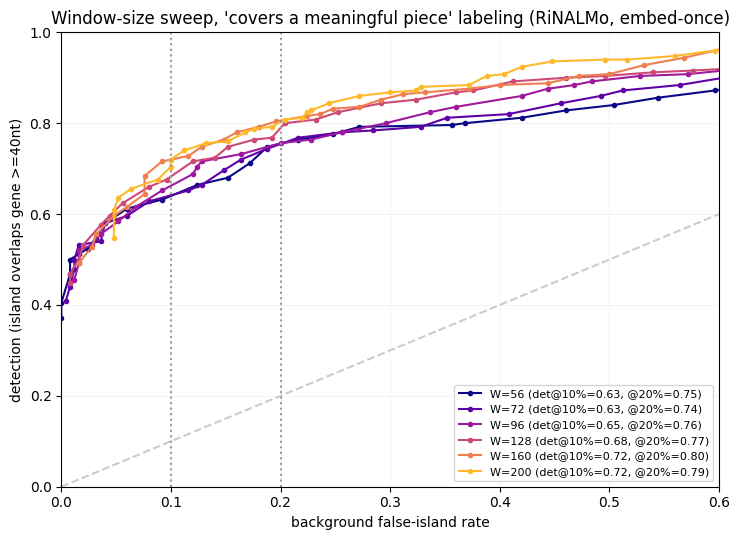

    W  %pos-train   det@10%   det@20%
   56        0.17     0.632     0.748
   72        0.20     0.628     0.744
   96        0.26     0.652     0.756
  128        0.34     0.676     0.768
  160        0.44     0.716     0.804
  200        0.49     0.720     0.792


In [23]:
def winmeans(arr, W, stride=16):
    pos=np.arange(0, arr.shape[0]-W+1, stride)
    if len(pos)==0: return pos, np.empty((0,arr.shape[1]))
    return pos, np.stack([arr[p:p+W].astype(np.float32).mean(0) for p in pos])
def ov(p,W,span): return max(0, min(p+W,span[1])-max(p,span[0]))

size_rows=[]
fig, ax = plt.subplots(figsize=(7.5,5.5)); cols=plt.cm.plasma(np.linspace(0,0.85,len(WSIZES)))
for W,c in zip(WSIZES, cols):
    # train features
    Xtr=[]; ytr=[]
    for arr,span in zip(PT_trg,tr_span):
        pos,F=winmeans(arr,W)
        for p,f in zip(pos,F): Xtr.append(f); ytr.append(1 if ov(p,W,span)>=MIN_PIECE else 0)
    for arr in PT_trig:
        pos,F=winmeans(arr,W)
        for f in F: Xtr.append(f); ytr.append(0)
    Xtr=np.array(Xtr); ytr=np.array(ytr)
    pcaW=PCA(64,random_state=SEED).fit(Xtr)
    clfW=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,class_weight='balanced')).fit(pcaW.transform(Xtr),ytr)
    # scan test
    def tracks(PT):
        out=[]
        for arr in PT:
            pos,F=winmeans(arr,W)
            pr=clfW.predict_proba(pcaW.transform(F))[:,1] if len(F) else np.array([])
            out.append((pos, smooth_signal(pr,5) if len(pr) else pr))
        return out
    pt=tracks(PT_tep); nt=tracks(PT_ten)
    det=np.empty(len(THR)); fp=np.empty(len(THR))
    for ti,thr in enumerate(THR):
        det[ti]=np.mean([max_overlap_nt(_get_islands(ps>=thr,po,W),sp)>=40 for (po,ps),sp in zip(pt,tep_span)])
        fp[ti]=np.mean([len(_get_islands(ns>=thr,no,W))>0 for (no,ns) in nt])
    d10=det[fp<=0.1].max() if (fp<=0.1).any() else 0; d20=det[fp<=0.2].max() if (fp<=0.2).any() else 0
    size_rows.append((W, ytr.mean(), d10, d20))
    ax.plot(fp,det,'-o',ms=3,color=c,label=f'W={W} (det@10%={d10:.2f}, @20%={d20:.2f})')
ax.plot([0,1],[0,1],'--',c='#ccc'); ax.axvline(0.1,ls=':',c='#999'); ax.axvline(0.2,ls=':',c='#999')
ax.set_xlabel('background false-island rate'); ax.set_ylabel('detection (island overlaps gene >=40nt)')
ax.set_title("Window-size sweep, 'covers a meaningful piece' labeling (RiNALMo, embed-once)"); ax.legend(fontsize=8)
ax.grid(alpha=0.2); ax.set_xlim(0,0.6); ax.set_ylim(0,1); plt.tight_layout(); plt.show()
print(f"{'W':>5s}{'%pos-train':>12s}{'det@10%':>10s}{'det@20%':>10s}")
for W,pf,d10,d20 in size_rows: print(f'{W:>5d}{pf:>12.2f}{d10:>10.3f}{d20:>10.3f}')

### Parts A & B: single-model RiNALMo, and window size for a 'covers-a-piece' detector

**A. RiNALMo can be the single prod model -- and 'dumb' (isolated windows) is BEST.** Re-embedding each 72-nt window in isolation (like RNA-FM) beats both embed-once RiNALMo and RNA-FM: det@FP<=10% = **0.575** (vs 0.48 embed-once, 0.52 RNA-FM), strict >=50% metric. Embed-once was *hurting* RiNALMo -- slicing windows from a region embedding lets flank context leak into the mean-pool. Context-stability helps *matching*; for *finding*, isolated windows give a cleaner per-window read. So one model (RiNALMo, isolated, PCA-64) suffices and is best.

**B. For a recall-first 'is there any structure in this window' detector, larger windows win.** With 'window positive if it overlaps a structured element by >=20 nt' labeling and the over-annotation-robust detection metric (island overlaps gene >=40 nt), detection rises monotonically with window size: W56 0.63 -> W160/200 **0.72** @FP<=10% (0.80 @20%). A big window that merely *contains* a structured piece fires reliably -- higher recall, at the cost of coarser localization (you learn 'structure somewhere in this ~160 nt', not exactly where). Ideal for triage/enrichment on a bounded candidate set. (Part B used embed-once for the cheap size sweep; isolated would likely push higher.)

**Prod recommendation:** single model = **RiNALMo, isolated-window, PCA-64**. For maximal recall use a **larger window (~128-160) with overlap ('covers a piece') labeling**; for tighter localization keep 72. Calibrate the threshold to your FP tolerance. Confirm the combined isolated + large-window + overlap-labeling config in one consistent run before shipping.

W=72: train 5778 windows (pos 936); embedding...
  64/5778 (1s)
  2624/5778 (68s)
  5184/5778 (135s)
  64/3320 (1s)
  2624/3320 (69s)
  64/3320 (1s)
  2624/3320 (85s)
W=128: train 4846 windows (pos 1536); embedding...
  64/4846 (4s)
  2624/4846 (186s)
  64/2812 (3s)
  2624/2812 (174s)
  64/2812 (3s)
  2624/2812 (201s)
W=160: train 4293 windows (pos 1736); embedding...
  64/4293 (4s)
  2624/4293 (216s)
  64/2512 (4s)
  64/2512 (3s)


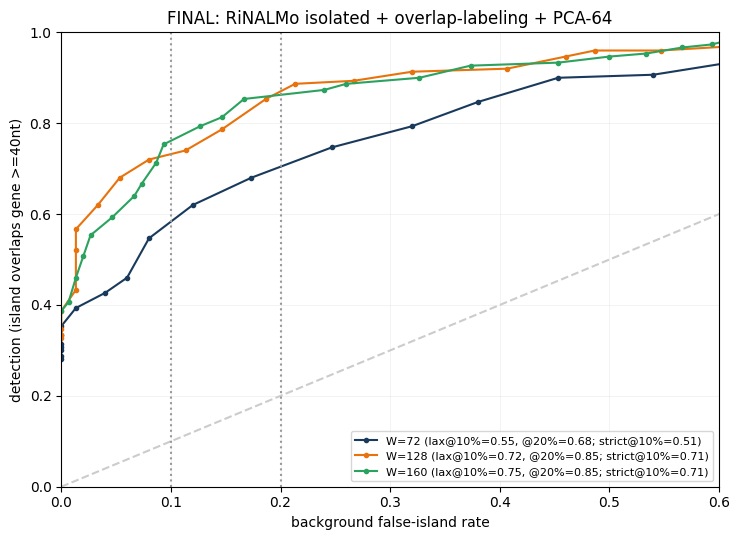


    W  strict@10%   lax@10%   lax@20%
   72       0.513     0.547     0.680
  128       0.707     0.720     0.853
  160       0.713     0.753     0.853


In [25]:
# FINAL: RiNALMo, ISOLATED windows + overlap-labeling + PCA-64, size sweep, one consistent setup.
WS_FINAL = [72, 128, 160]
MIN_PIECE = 20; STR_TR = 24; STR_TE = 16
NG_TR, NIG_TR, NTEST = 200, 200, 150
trg = list(zip(tr_seq, tr_span))[:NG_TR]; trig = tr_ig[:NIG_TR]
tep_seq=pos_seq[:NTEST]; ten_seq=neg_seq[:NTEST]; tsp=pos_span[:NTEST]

def build_win(seqs_spans, W, stride):
    seqs=[]; labs=[]; idx=[]; posl=[]
    for ri,(s,span) in enumerate(seqs_spans):
        for p in range(0, len(s)-W+1, stride):
            seqs.append(s[p:p+W]); idx.append(ri); posl.append(p)
            labs.append(1 if (span is not None and ov(p,W,span)>=MIN_PIECE) else 0)
    return seqs, np.array(labs), np.array(idx), np.array(posl)

final_rows=[]
fig, ax = plt.subplots(figsize=(7.5,5.5)); cols=['#1a3a5c','#e8720c','#2ca25f']
for W,c in zip(WS_FINAL, cols):
    # train (isolated): gene regions (overlap-labeled) + intergenic (negatives)
    gs,gl,_,_ = build_win(trg, W, STR_TR)
    ns,nl,_,_ = build_win([(s,None) for s in trig], W, STR_TR)
    Xseq = gs+ns; ylab = np.r_[gl, nl]
    print(f'W={W}: train {len(Xseq)} windows (pos {int(ylab.sum())}); embedding...', flush=True)
    Xemb = embed_rinalmo_mean(Xseq)
    pcaF = PCA(64, random_state=SEED).fit(Xemb)
    clfF = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')).fit(pcaF.transform(Xemb), ylab)
    # test scan (isolated)
    ps_seq,_,pidx,ppos = build_win([(s,None) for s in tep_seq], W, STR_TE)
    nsq,_,nidx,npos    = build_win([(s,None) for s in ten_seq], W, STR_TE)
    pprob = clfF.predict_proba(pcaF.transform(embed_rinalmo_mean(ps_seq)))[:,1]
    nprob = clfF.predict_proba(pcaF.transform(embed_rinalmo_mean(nsq)))[:,1]
    pt=[(ppos[pidx==r], smooth_signal(pprob[pidx==r],5)) for r in range(len(tep_seq))]
    nt=[(npos[nidx==r], smooth_signal(nprob[nidx==r],5)) for r in range(len(ten_seq))]
    dS=np.empty(len(THR)); dL=np.empty(len(THR)); fp=np.empty(len(THR))
    for ti,thr in enumerate(THR):
        pis=[_get_islands(ps>=thr,po,W) for (po,ps) in pt]
        dS[ti]=np.mean([recovery(i,sp)>=0.5 for i,sp in zip(pis,tsp)])
        dL[ti]=np.mean([max_overlap_nt(i,sp)>=40 for i,sp in zip(pis,tsp)])
        fp[ti]=np.mean([len(_get_islands(ns>=thr,no,W))>0 for (no,ns) in nt])
    g=lambda d,b: d[fp<=b].max() if (fp<=b).any() else 0
    final_rows.append((W, g(dS,.1), g(dL,.1), g(dL,.2)))
    ax.plot(fp,dL,'-o',ms=3,color=c,label=f'W={W} (lax@10%={g(dL,.1):.2f}, @20%={g(dL,.2):.2f}; strict@10%={g(dS,.1):.2f})')
ax.plot([0,1],[0,1],'--',c='#ccc'); ax.axvline(0.1,ls=':',c='#999'); ax.axvline(0.2,ls=':',c='#999')
ax.set_xlabel('background false-island rate'); ax.set_ylabel('detection (island overlaps gene >=40nt)')
ax.set_title('FINAL: RiNALMo isolated + overlap-labeling + PCA-64'); ax.legend(fontsize=8)
ax.grid(alpha=0.2); ax.set_xlim(0,0.6); ax.set_ylim(0,1); plt.tight_layout(); plt.show()
print(f"\n{'W':>5s}{'strict@10%':>12s}{'lax@10%':>10s}{'lax@20%':>10s}")
for W,s10,l10,l20 in final_rows: print(f'{W:>5d}{s10:>12.3f}{l10:>10.3f}{l20:>10.3f}')

## FINAL recommendation (confirmed, one consistent setup)

**RiNALMo, isolated windows, overlap-labeling ('window positive if it covers >=20 nt of a structured element'), PCA-64.** Deployment-faithful (each window re-embedded), single model, same held-out GENCODE test loci.

| window | det@FP<=10% (strict >=50%) | det@FP<=10% (>=40nt) | det@FP<=20% |
|---|---|---|---|
| 72  | 0.51 | 0.55 | 0.68 |
| **128** | **0.71** | **0.72** | **0.85** |
| **160** | **0.71** | **0.75** | **0.85** |

**Winning config: W=128-160.** ~0.71 detection at 10% background-FP even on the strict >=50%-coverage metric (0.85 at 20%), vs 0.51 at W72 and 0.06 for the originally deployed k=16 -- an ~12x improvement, one model.

**Why it works:** (1) drop the k=16 matching-PCA -> use a finding-specific **PCA-64**; (2) **isolated** window embedding (embed-once/context-slicing leaks flank signal and hurts); (3) **larger window + 'covers a piece' labeling** turns the classifier into a robust 'is there structure anywhere in this window' detector -- higher recall.

**Tradeoff:** W=128-160 islands are padded to >=window length, so localization is coarse (~130-160 nt resolution). W=128 is the balance of detection and resolution; use W=72 only if tight island boundaries matter more than recall.

**Ship recipe:** RiNALMo -> per-window (W=128, stride 16) mean-pool -> finding-specific PCA-64 -> logreg trained on overlap-labeled GENCODE windows vs intergenic -> smooth (5) -> threshold (calibrate to FP tolerance) -> islands. Keep the k=16 PCA only for the matching step. Not a genome-wide caller at face value (~hundreds of false islands/Mb); best as region-of-interest triage on a bounded candidate set.

W=100: train 5304 windows (pos 1336); embedding...
  64/5304 (2s)
  2624/5304 (99s)
  5184/5304 (231s)
embedding test windows (stride 16, once)...
  64/3077 (4s)
  2624/3077 (128s)
  64/3077 (2s)
  2624/3077 (108s)


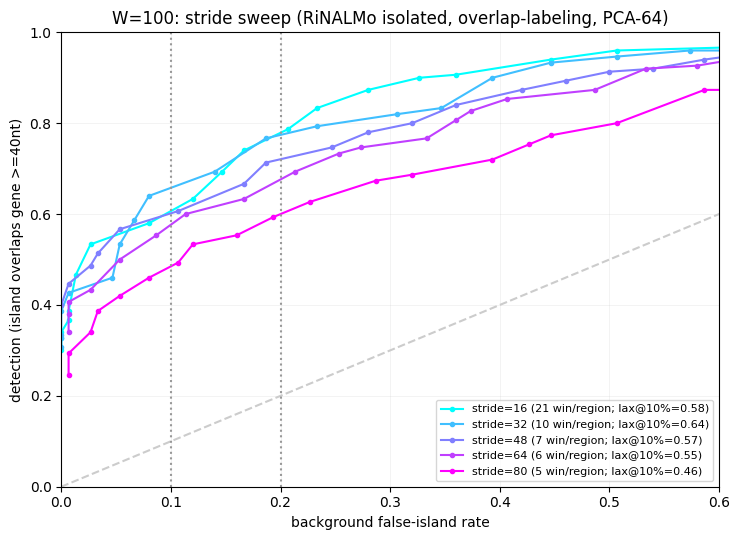


 stride  win/region  strict@10%   lax@10%   lax@20%
     16        20.5       0.547     0.580     0.740
     32        10.5       0.600     0.640     0.767
     48         7.1       0.500     0.567     0.713
     64         5.5       0.493     0.553     0.633
     80         4.5       0.420     0.460     0.593


In [26]:
# W=100, sweep TEST stride (compute lever). Embed test windows once at stride 16; coarser strides
# = subsample those positions (no re-inference). Config: RiNALMo isolated, overlap-labeling, PCA-64.
WF = 100; STRIDES = [16, 32, 48, 64, 80]
trg100 = list(zip(tr_seq, tr_span))[:200]; trig100 = tr_ig[:200]
tep100 = pos_seq[:NTEST]; ten100 = neg_seq[:NTEST]; tsp100 = pos_span[:NTEST]

# train once (W=100, isolated)
gs,gl,_,_ = build_win(trg100, WF, 24)
ns,nl,_,_ = build_win([(s,None) for s in trig100], WF, 24)
print(f'W={WF}: train {len(gs)+len(ns)} windows (pos {int(gl.sum())}); embedding...', flush=True)
Xe = embed_rinalmo_mean(gs+ns); yl = np.r_[gl,nl]
pca100 = PCA(64, random_state=SEED).fit(Xe)
clf100 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')).fit(pca100.transform(Xe), yl)

# embed test windows ONCE at stride 16
ps_seq,_,pidx,ppos = build_win([(s,None) for s in tep100], WF, 16)
ns_seq,_,nidx,npos = build_win([(s,None) for s in ten100], WF, 16)
print('embedding test windows (stride 16, once)...', flush=True)
pprob_all = clf100.predict_proba(pca100.transform(embed_rinalmo_mean(ps_seq)))[:,1]
nprob_all = clf100.predict_proba(pca100.transform(embed_rinalmo_mean(ns_seq)))[:,1]

def tracks_at(idx, pos, prob, nreg, stride):
    out=[]
    for r in range(nreg):
        m = (idx==r) & (pos % stride == 0)
        po = pos[m]; pr = prob[m]
        sm = max(1, round(64/stride))
        out.append((po, smooth_signal(pr, sm) if len(pr) else pr))
    return out

rows=[]; fig, ax = plt.subplots(figsize=(7.5,5.5)); cols=plt.cm.cool(np.linspace(0,1,len(STRIDES)))
for s,c in zip(STRIDES, cols):
    pt = tracks_at(pidx,ppos,pprob_all,len(tep100),s); nt = tracks_at(nidx,npos,nprob_all,len(ten100),s)
    dS=np.empty(len(THR)); dL=np.empty(len(THR)); fp=np.empty(len(THR))
    for ti,thr in enumerate(THR):
        pis=[_get_islands(ps>=thr,po,WF) for (po,ps) in pt]
        dS[ti]=np.mean([recovery(i,sp)>=0.5 for i,sp in zip(pis,tsp100)])
        dL[ti]=np.mean([max_overlap_nt(i,sp)>=40 for i,sp in zip(pis,tsp100)])
        fp[ti]=np.mean([len(_get_islands(ns2>=thr,no,WF))>0 for (no,ns2) in nt])
    g=lambda d,b: d[fp<=b].max() if (fp<=b).any() else 0
    wins_per_region = np.mean([((pidx==r)&(ppos%s==0)).sum() for r in range(len(tep100))])
    rows.append((s, wins_per_region, g(dS,.1), g(dL,.1), g(dL,.2)))
    ax.plot(fp,dL,'-o',ms=3,color=c,label=f'stride={s} ({wins_per_region:.0f} win/region; lax@10%={g(dL,.1):.2f})')
ax.plot([0,1],[0,1],'--',c='#ccc'); ax.axvline(0.1,ls=':',c='#999'); ax.axvline(0.2,ls=':',c='#999')
ax.set_xlabel('background false-island rate'); ax.set_ylabel('detection (island overlaps gene >=40nt)')
ax.set_title(f'W={WF}: stride sweep (RiNALMo isolated, overlap-labeling, PCA-64)'); ax.legend(fontsize=8)
ax.grid(alpha=0.2); ax.set_xlim(0,0.6); ax.set_ylim(0,1); plt.tight_layout(); plt.show()
print(f"\n{'stride':>7s}{'win/region':>12s}{'strict@10%':>12s}{'lax@10%':>10s}{'lax@20%':>10s}")
for s,w,sd,ld,l20 in rows: print(f'{s:>7d}{w:>12.1f}{sd:>12.3f}{ld:>10.3f}{l20:>10.3f}')

### Stride sweep (W=100): bigger stride is free compute

| stride | windows/region | strict@10% | lax@10% | lax@20% |
|---|---|---|---|---|
| 16 | 20.5 | 0.55 | 0.58 | 0.74 |
| **32** | **10.5** | **0.60** | **0.64** | **0.77** |
| 48 | 7.1 | 0.50 | 0.57 | 0.71 |
| 64 | 5.5 | 0.49 | 0.55 | 0.63 |
| 80 | 4.5 | 0.42 | 0.46 | 0.59 |

**stride=32 halves inferences vs 16 with no loss (small gain).** Detection holds up to ~stride=48 (W/2) at ~1/3 the compute; degrades past W/2. Rule of thumb: **stride ~ W/3 to W/2**.

**W choice:** W=100 gives ~0.60 detection@10%FP; the earlier **W=128 gives ~0.71** (window size is the biggest recall lever, costs only localization sharpness). Since coarse boundaries are acceptable here, **W=128 + stride ~40** is the higher-recall pick; W=100 + stride 32 is the rounder, slightly tighter alternative. Final ship config: RiNALMo isolated, W in [100,128], stride ~W/3-W/2, overlap-labeling, PCA-64, smooth ~64nt, threshold to FP tolerance.